# Color Histogram for Image Retrieval — Research Deep Dive with White-Box Code

**Task context:** Image–Image Matching / Content-Based Image Retrieval (CBIR)  
**Main question:** How far can we go by representing an image only with its color distribution?

This notebook is designed as both:
1. a **research note** for color-histogram based image retrieval, and  
2. a **white-box implementation notebook** that shows how the functions actually work internally.

Every major concept is followed by code, visualization, or an experiment.

## Learning goals

By the end, you should be able to explain and implement:

- What a color histogram represents.
- How color quantization maps pixels into histogram bins.
- How raw counts become normalized descriptors.
- How similarity functions rank images.
- Why color histograms are fast and useful.
- Why they fail when spatial layout, shape, or semantics matter.
- How to improve them using spatial histograms, color layout, or feature fusion.

## 0. Research context and paper anchors

Color histograms are one of the earliest and simplest descriptors for **content-based image retrieval**. They represent an image using the distribution of colors, ignoring exact object shape and pixel location.

Important references:

| Paper / System | Why it matters |
|---|---|
| **Swain & Ballard, 1991 — Color Indexing** | Introduced color histograms and histogram intersection for object indexing/retrieval. |
| **QBIC, Flickner et al., 1995** | One of the classic early CBIR systems using visual content such as color, texture, and shape. |
| **Stricker & Orengo, 1995 — Color Moments** | Compact alternative to full histograms using statistical color moments. |
| **Huang et al., 1997 — Color Correlogram** | Added spatial correlation of colors, addressing a major weakness of global histograms. |
| **Smeulders et al., 2000 — CBIR survey** | Classic survey of early CBIR systems and the semantic gap. |
| **MPEG-7 color descriptors, Manjunath et al., 2001** | Standardized visual descriptors including scalable color, color layout, and color structure. |
| **Zhou, Li & Tian, 2017 — CBIR survey** | Modern taxonomy: representation, indexing, similarity, re-ranking. |

The notebook uses these works as motivation, then turns the ideas into runnable code.

In [ ]:
# If you run this notebook in a fresh environment, uncomment the next line.
# %pip install numpy matplotlib pandas scikit-image scikit-learn scipy

import math
import inspect
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from skimage import data, color, transform, filters
from skimage.feature import hog

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = False

OUTPUT_DIR = Path("/mnt/data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1. Visual taxonomy: where color histograms fit in image matching

Image matching methods can be grouped by the visual signal they encode.

Color histograms are **global, hand-crafted, low-level descriptors**.  
They are cheap and easy to compute, but they do not understand objects.

,family,examples,captures,spatial_layout
0,Global low-level,"Color histogram, color moments, GIST",overall appearance,weak / none
1,Local keypoint,"SIFT, SURF, ORB",local distinctive patches,via matching geometry
2,Gradient/texture,"HOG, LBP, Gabor","edges, shape, texture",medium
3,Region/spatial color,"Spatial histograms, color correlogram, color l...",color + coarse layout,stronger
4,Deep embeddings,"CNN, ViT, DINO, CLIP",learned semantics,learned


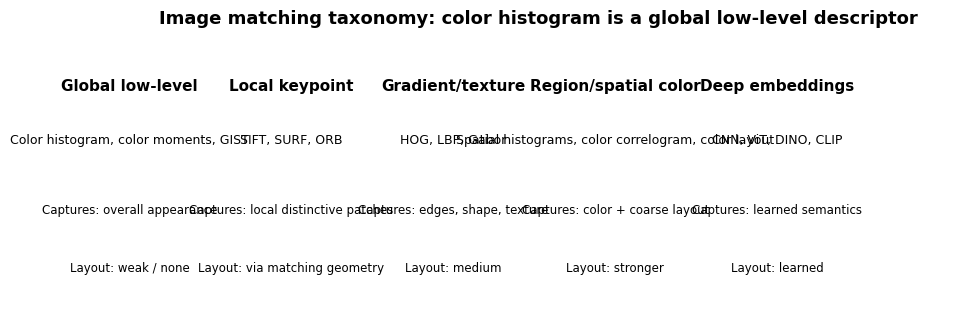

In [ ]:
taxonomy = pd.DataFrame([
    {"family": "Global low-level", "examples": "Color histogram, color moments, GIST", "captures": "overall appearance", "spatial_layout": "weak / none"},
    {"family": "Local keypoint", "examples": "SIFT, SURF, ORB", "captures": "local distinctive patches", "spatial_layout": "via matching geometry"},
    {"family": "Gradient/texture", "examples": "HOG, LBP, Gabor", "captures": "edges, shape, texture", "spatial_layout": "medium"},
    {"family": "Region/spatial color", "examples": "Spatial histograms, color correlogram, color layout", "captures": "color + coarse layout", "spatial_layout": "stronger"},
    {"family": "Deep embeddings", "examples": "CNN, ViT, DINO, CLIP", "captures": "learned semantics", "spatial_layout": "learned"},
])

display(taxonomy)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.axis("off")
y = 0.8
for i, row in taxonomy.iterrows():
    x = 0.02 + i*0.19
    ax.text(x, y, row["family"], fontsize=11, weight="bold", ha="center")
    ax.text(x, y-0.18, row["examples"], fontsize=9, ha="center", wrap=True)
    ax.text(x, y-0.42, "Captures: " + row["captures"], fontsize=8.5, ha="center", wrap=True)
    ax.text(x, y-0.62, "Layout: " + row["spatial_layout"], fontsize=8.5, ha="center", wrap=True)
ax.set_title("Image matching taxonomy: color histogram is a global low-level descriptor", fontsize=13, weight="bold")
plt.show()

## 2. Paper timeline visualization

This section helps you tell the story:

> **Color histogram → color moments/correlogram → MPEG-7 descriptors → local features/deep features**

Color histograms are historically important because they show the basic CBIR idea:  
**extract a fixed-length visual vector, compare vectors, rank images.**

,year,work,authors,main_idea
0,1991,Color Indexing,Swain & Ballard,Color histograms + histogram intersection
1,1995,QBIC,Flickner et al.,"Early CBIR system using color, texture, shape"
2,1995,Color Moments,Stricker & Orengo,Mean/variance/skewness as compact color descri...
3,1997,Color Correlogram,Huang et al.,Color co-occurrence across pixel distances
4,2000,CBIR early-years survey,Smeulders et al.,Semantic gap and early CBIR taxonomy
5,2001,MPEG-7 color descriptors,Manjunath et al.,Standardized color/texture descriptors
6,2017,Recent CBIR survey,"Zhou, Li & Tian","Representation, indexing, similarity, re-ranking"


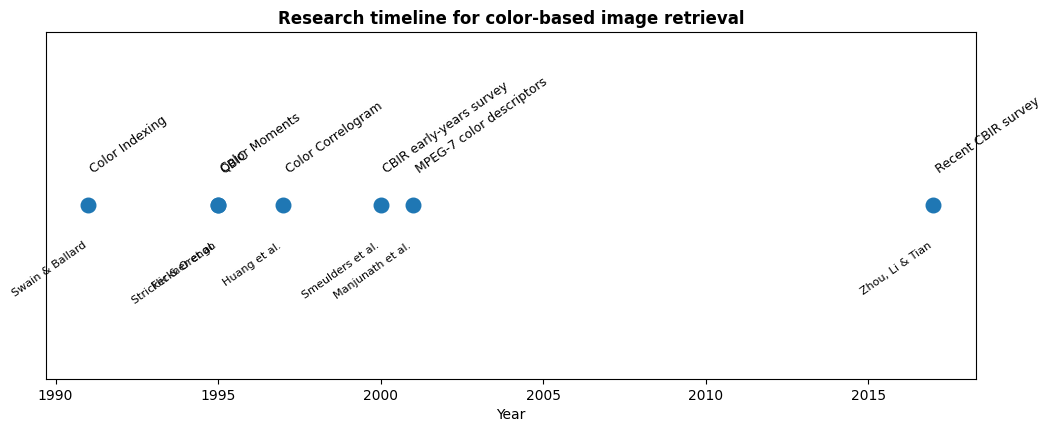

In [ ]:
paper_timeline = pd.DataFrame([
    {"year": 1991, "work": "Color Indexing", "authors": "Swain & Ballard", "main_idea": "Color histograms + histogram intersection"},
    {"year": 1995, "work": "QBIC", "authors": "Flickner et al.", "main_idea": "Early CBIR system using color, texture, shape"},
    {"year": 1995, "work": "Color Moments", "authors": "Stricker & Orengo", "main_idea": "Mean/variance/skewness as compact color descriptor"},
    {"year": 1997, "work": "Color Correlogram", "authors": "Huang et al.", "main_idea": "Color co-occurrence across pixel distances"},
    {"year": 2000, "work": "CBIR early-years survey", "authors": "Smeulders et al.", "main_idea": "Semantic gap and early CBIR taxonomy"},
    {"year": 2001, "work": "MPEG-7 color descriptors", "authors": "Manjunath et al.", "main_idea": "Standardized color/texture descriptors"},
    {"year": 2017, "work": "Recent CBIR survey", "authors": "Zhou, Li & Tian", "main_idea": "Representation, indexing, similarity, re-ranking"},
])

display(paper_timeline)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.scatter(paper_timeline["year"], np.zeros(len(paper_timeline)), s=110)
for _, row in paper_timeline.iterrows():
    ax.text(row["year"], 0.06, row["work"], rotation=35, ha="left", va="bottom", fontsize=9)
    ax.text(row["year"], -0.07, row["authors"], rotation=35, ha="right", va="top", fontsize=8)
ax.set_ylim(-0.35, 0.35)
ax.set_yticks([])
ax.set_xlabel("Year")
ax.set_title("Research timeline for color-based image retrieval", weight="bold")
plt.show()

## 3. The core idea: turn pixels into a distribution

A color histogram counts how many pixels fall into each color bin.

For an RGB image:

\[
I(x,y) = (R,G,B)
\]

we quantize each channel into bins, then count how many pixels belong to each bin.

Example with 4 bins per RGB channel:

\[
\text{dimension} = 4 \times 4 \times 4 = 64
\]

This is why histograms are fixed-length even when images have different sizes.

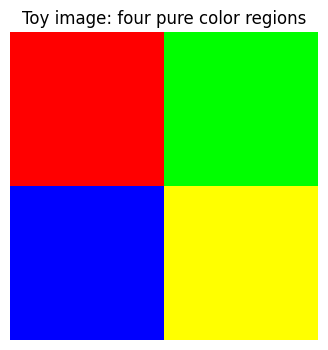

,R,G,B
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
5,0.0,0.0,1.0
6,0.0,0.0,1.0
7,0.0,0.0,1.0


In [ ]:
def make_color_blocks(block_size=48):
    """Create a simple image with clear color blocks for histogram visualization."""
    colors = np.array([
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [1, 1, 0],
    ], dtype=float)
    img = np.zeros((block_size*2, block_size*2, 3), dtype=float)
    img[:block_size, :block_size] = colors[0]
    img[:block_size, block_size:] = colors[1]
    img[block_size:, :block_size] = colors[2]
    img[block_size:, block_size:] = colors[3]
    return img

toy_img = make_color_blocks()

plt.figure(figsize=(4, 4))
plt.imshow(toy_img)
plt.title("Toy image: four pure color regions")
plt.axis("off")
plt.show()

sample_pixels = toy_img.reshape(-1, 3)
display(pd.DataFrame(sample_pixels[::len(sample_pixels)//8], columns=["R", "G", "B"]).head(8))

## 4. White-box function 1: quantization

Before counting colors, we must decide what counts as “similar enough”.

A pixel value is continuous or 8-bit discrete, but histogram bins are coarse.  
Quantization maps values into bin IDs.

For one channel:

\[
\text{bin}(v) = \left\lfloor v \times n_\text{bins} \right\rfloor
\]

with clipping so that value `1.0` goes into the last bin, not outside the array.

,value,bin_id_with_2_bins
0,0.00,0
1,0.05,0
2,0.24,0
3,0.25,0
4,0.49,0
5,0.50,1
6,0.74,1
7,0.75,1
8,0.99,1
9,1.00,1


,value,bin_id_with_4_bins
0,0.00,0
1,0.05,0
2,0.24,0
3,0.25,1
4,0.49,1
5,0.50,2
6,0.74,2
7,0.75,3
8,0.99,3
9,1.00,3


,value,bin_id_with_8_bins
0,0.00,0
1,0.05,0
2,0.24,1
3,0.25,2
4,0.49,3
5,0.50,4
6,0.74,5
7,0.75,6
8,0.99,7
9,1.00,7


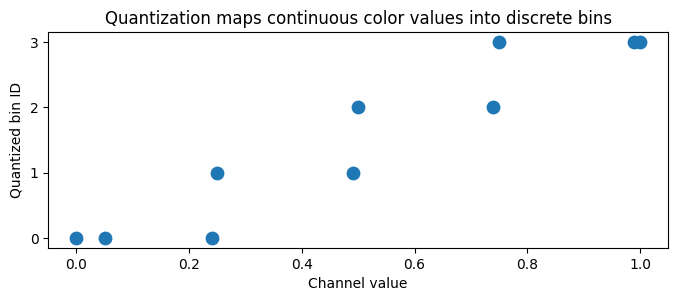

In [ ]:
def quantize_channel(channel, bins):
    """
    Map values in [0, 1] to integer bin IDs: 0, 1, ..., bins-1.
    """
    q = np.floor(channel * bins).astype(int)
    q = np.clip(q, 0, bins - 1)
    return q

values = np.array([0.00, 0.05, 0.24, 0.25, 0.49, 0.50, 0.74, 0.75, 0.99, 1.00])
for bins in [2, 4, 8]:
    demo = pd.DataFrame({
        "value": values,
        f"bin_id_with_{bins}_bins": quantize_channel(values, bins)
    })
    display(demo)

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.scatter(values, quantize_channel(values, 4), s=80)
ax.set_xlabel("Channel value")
ax.set_ylabel("Quantized bin ID")
ax.set_title("Quantization maps continuous color values into discrete bins")
ax.set_yticks([0, 1, 2, 3])
plt.show()

## 5. White-box function 2: RGB bin indexing

For a 3D RGB histogram, each pixel has three bin IDs:

\[
(r_\text{bin}, g_\text{bin}, b_\text{bin})
\]

To store a 3D histogram as a 1D vector, we flatten the 3D bin coordinate:

\[
\text{flat\_id} = r_\text{bin} \times n^2 + g_\text{bin} \times n + b_\text{bin}
\]

This section shows the actual internal IDs used by the histogram function.

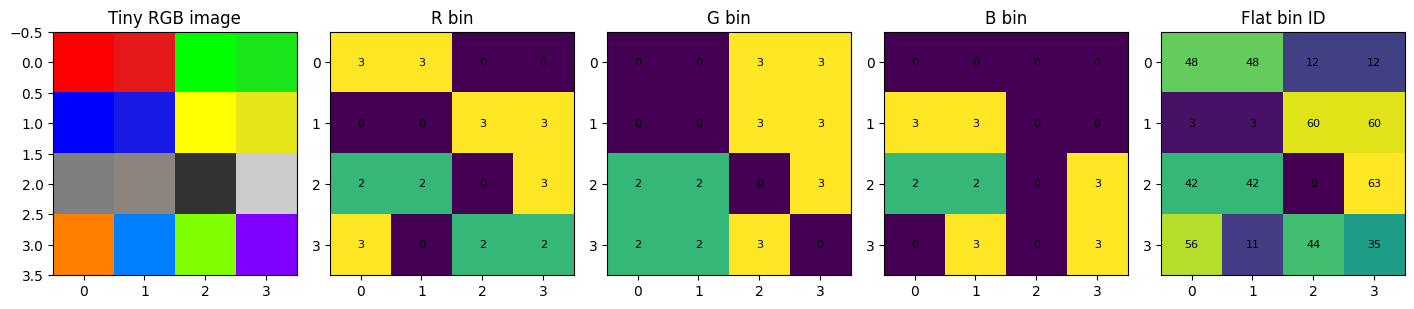

,y,x,R,G,B,r_bin,g_bin,b_bin,flat_bin_id
0,0,0,1.00,0.00,0.0,3,0,0,48
1,0,1,0.90,0.10,0.1,3,0,0,48
2,0,2,0.00,1.00,0.0,0,3,0,12
3,0,3,0.10,0.90,0.1,0,3,0,12
4,1,0,0.00,0.00,1.0,0,0,3,3
5,1,1,0.10,0.10,0.9,0,0,3,3
6,1,2,1.00,1.00,0.0,3,3,0,60
7,1,3,0.90,0.90,0.1,3,3,0,60
8,2,0,0.50,0.50,0.5,2,2,2,42
9,2,1,0.55,0.52,0.5,2,2,2,42


In [ ]:
def rgb_flat_bin_ids(image_rgb, bins=4):
    """
    Convert every RGB pixel into channel-wise bin IDs and one flattened histogram bin ID.
    """
    img = np.clip(image_rgb, 0, 1)
    r_bin = quantize_channel(img[..., 0], bins)
    g_bin = quantize_channel(img[..., 1], bins)
    b_bin = quantize_channel(img[..., 2], bins)
    flat_id = r_bin * (bins ** 2) + g_bin * bins + b_bin
    return r_bin, g_bin, b_bin, flat_id

tiny = np.array([
    [[1.0, 0.0, 0.0], [0.9, 0.1, 0.1], [0.0, 1.0, 0.0], [0.1, 0.9, 0.1]],
    [[0.0, 0.0, 1.0], [0.1, 0.1, 0.9], [1.0, 1.0, 0.0], [0.9, 0.9, 0.1]],
    [[0.5, 0.5, 0.5], [0.55, 0.52, 0.50], [0.2, 0.2, 0.2], [0.8, 0.8, 0.8]],
    [[1.0, 0.5, 0.0], [0.0, 0.5, 1.0], [0.5, 1.0, 0.0], [0.5, 0.0, 1.0]]
], dtype=float)

r_bin, g_bin, b_bin, flat_id = rgb_flat_bin_ids(tiny, bins=4)

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(tiny)
axes[0].set_title("Tiny RGB image")
for ax, arr, title in zip(axes[1:], [r_bin, g_bin, b_bin, flat_id], ["R bin", "G bin", "B bin", "Flat bin ID"]):
    ax.imshow(arr)
    ax.set_title(title)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    for y in range(arr.shape[0]):
        for x in range(arr.shape[1]):
            ax.text(x, y, str(arr[y, x]), ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()

rows = []
for y in range(tiny.shape[0]):
    for x in range(tiny.shape[1]):
        rows.append({
            "y": y, "x": x,
            "R": tiny[y, x, 0], "G": tiny[y, x, 1], "B": tiny[y, x, 2],
            "r_bin": r_bin[y, x], "g_bin": g_bin[y, x], "b_bin": b_bin[y, x],
            "flat_bin_id": flat_id[y, x]
        })
display(pd.DataFrame(rows))

## 6. White-box function 3: manual RGB histogram

Now we count how often each flattened bin ID appears.

This is the histogram.  
No magic. Just counting.

,flat_bin_id,count
0,0,1
1,3,2
2,11,1
3,12,2
4,35,1
5,42,2
6,44,1
7,48,2
8,56,1
9,60,2


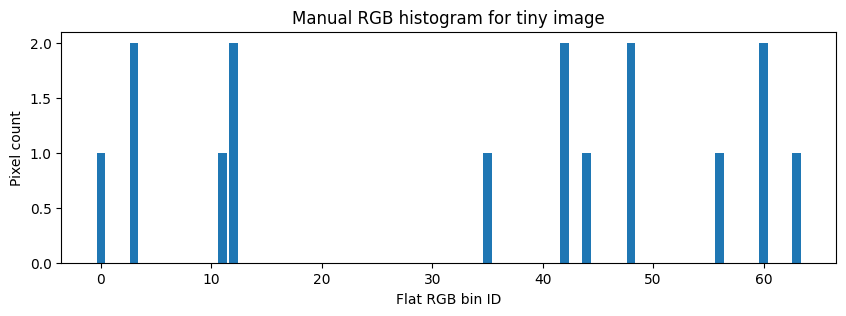

Histogram length: 64 = bins^3 = 64
Total counted pixels: 16.0 = 16


In [ ]:
def manual_rgb_histogram(image_rgb, bins=4, normalize_hist=True):
    """
    Manual RGB histogram implementation.

    Steps:
    1. Quantize R/G/B values into bins.
    2. Flatten 3D bin coordinates into 1D bin IDs.
    3. Count pixels per bin.
    4. Optionally L1-normalize so histogram sums to 1.
    """
    _, _, _, ids = rgb_flat_bin_ids(image_rgb, bins=bins)
    hist = np.zeros(bins ** 3, dtype=float)
    for idx in ids.ravel():
        hist[idx] += 1.0
    if normalize_hist:
        total = hist.sum()
        if total > 0:
            hist = hist / total
    return hist

hist_tiny = manual_rgb_histogram(tiny, bins=4, normalize_hist=False)
nonzero = np.where(hist_tiny > 0)[0]

display(pd.DataFrame({
    "flat_bin_id": nonzero,
    "count": hist_tiny[nonzero].astype(int)
}))

plt.figure(figsize=(10, 3))
plt.bar(np.arange(len(hist_tiny)), hist_tiny)
plt.xlabel("Flat RGB bin ID")
plt.ylabel("Pixel count")
plt.title("Manual RGB histogram for tiny image")
plt.show()

print("Histogram length:", len(hist_tiny), "= bins^3 =", 4**3)
print("Total counted pixels:", hist_tiny.sum(), "=", tiny.shape[0] * tiny.shape[1])

## 7. Checking our manual function against NumPy

Good research code should test simple assumptions.

Here we compare the manual implementation against `numpy.histogramdd`.

,bin_id,manual,numpy,absolute_difference
0,0,0.0625,0.0625,0.0
3,3,0.1250,0.1250,0.0
11,11,0.0625,0.0625,0.0
12,12,0.1250,0.1250,0.0
35,35,0.0625,0.0625,0.0
42,42,0.1250,0.1250,0.0
44,44,0.0625,0.0625,0.0
48,48,0.1250,0.1250,0.0
56,56,0.0625,0.0625,0.0
60,60,0.1250,0.1250,0.0


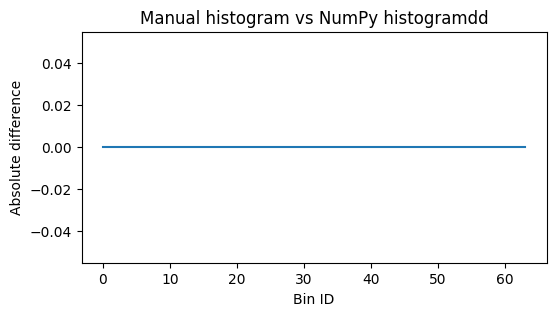

Max difference: 0.0


In [ ]:
def numpy_rgb_histogram(image_rgb, bins=4, normalize_hist=True):
    img = np.clip(image_rgb, 0, 1)
    pixels = img.reshape(-1, 3)
    hist3d, edges = np.histogramdd(
        pixels,
        bins=[bins, bins, bins],
        range=[(0, 1), (0, 1), (0, 1)]
    )
    hist = hist3d.astype(float).ravel()
    if normalize_hist and hist.sum() > 0:
        hist /= hist.sum()
    return hist

manual_hist = manual_rgb_histogram(tiny, bins=4, normalize_hist=True)
numpy_hist = numpy_rgb_histogram(tiny, bins=4, normalize_hist=True)

comparison = pd.DataFrame({
    "bin_id": np.arange(len(manual_hist)),
    "manual": manual_hist,
    "numpy": numpy_hist,
    "absolute_difference": np.abs(manual_hist - numpy_hist),
})
display(comparison[comparison["manual"] + comparison["numpy"] > 0])

plt.figure(figsize=(6, 3))
plt.plot(comparison["absolute_difference"])
plt.title("Manual histogram vs NumPy histogramdd")
plt.xlabel("Bin ID")
plt.ylabel("Absolute difference")
plt.show()

print("Max difference:", comparison["absolute_difference"].max())

## 8. Normalization: why raw counts are usually wrong for retrieval

Raw histogram counts depend on image size.  
A large image naturally has more pixels than a small image.

For retrieval, we usually compare **proportions**, not raw counts:

\[
h_i = \frac{\text{count}_i}{\sum_j \text{count}_j}
\]

This is called **L1 normalization**.

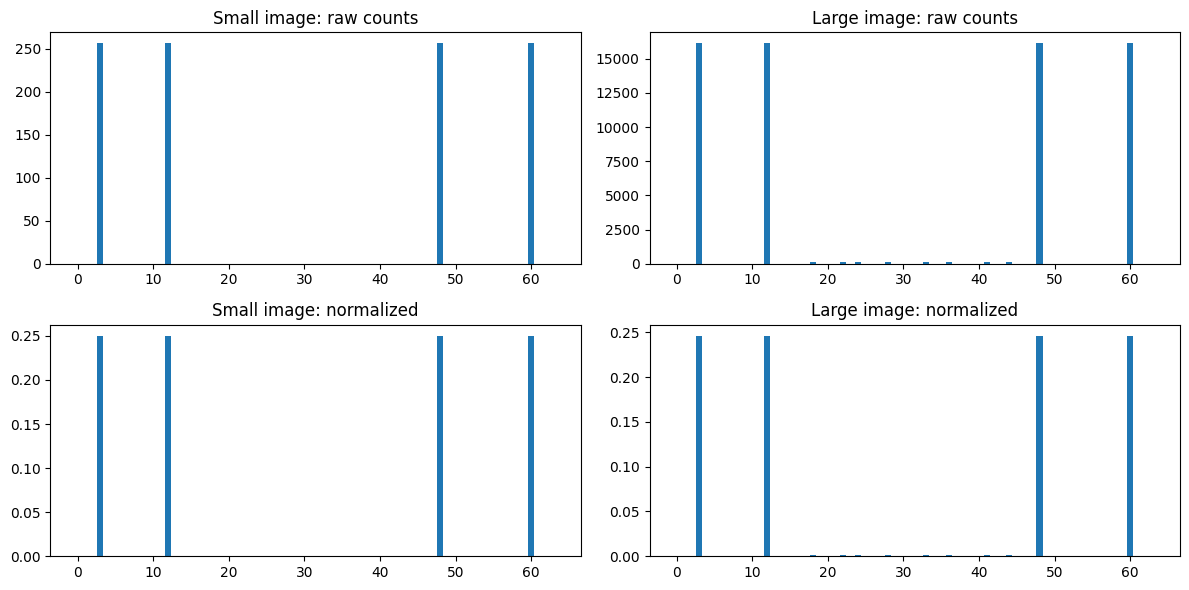

Raw count sum small: 1024.0
Raw count sum large: 65536.0
Normalized sum small: 1.0
Normalized sum large: 1.0
Max normalized difference: 0.0038909912109375


In [ ]:
small_img = transform.resize(toy_img, (32, 32), anti_aliasing=True)
large_img = transform.resize(toy_img, (256, 256), anti_aliasing=True)

raw_small = manual_rgb_histogram(small_img, bins=4, normalize_hist=False)
raw_large = manual_rgb_histogram(large_img, bins=4, normalize_hist=False)
norm_small = manual_rgb_histogram(small_img, bins=4, normalize_hist=True)
norm_large = manual_rgb_histogram(large_img, bins=4, normalize_hist=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes[0, 0].bar(np.arange(len(raw_small)), raw_small)
axes[0, 0].set_title("Small image: raw counts")
axes[0, 1].bar(np.arange(len(raw_large)), raw_large)
axes[0, 1].set_title("Large image: raw counts")
axes[1, 0].bar(np.arange(len(norm_small)), norm_small)
axes[1, 0].set_title("Small image: normalized")
axes[1, 1].bar(np.arange(len(norm_large)), norm_large)
axes[1, 1].set_title("Large image: normalized")
plt.tight_layout()
plt.show()

print("Raw count sum small:", raw_small.sum())
print("Raw count sum large:", raw_large.sum())
print("Normalized sum small:", norm_small.sum())
print("Normalized sum large:", norm_large.sum())
print("Max normalized difference:", np.max(np.abs(norm_small - norm_large)))

## 9. Utility functions for real images

Now we build the reusable functions used later in the retrieval experiments.

We keep them explicit and inspectable.

In [ ]:
def ensure_rgb(image):
    """
    Convert image to RGB float in [0, 1].
    Handles grayscale, RGBA, boolean, uint8, and float inputs.
    """
    img = np.asarray(image)

    if img.dtype == bool:
        img = img.astype(float)
    elif np.issubdtype(img.dtype, np.integer):
        img = img.astype(float) / np.iinfo(img.dtype).max
    else:
        img = img.astype(float)
        if img.max() > 1.0:
            img = img / 255.0

    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    elif img.ndim == 3 and img.shape[-1] == 4:
        img = img[..., :3]

    return np.clip(img, 0, 1)

def resize_image(image, size=(128, 128)):
    """Resize image to a fixed size for fair feature extraction and visualization."""
    return transform.resize(ensure_rgb(image), size, anti_aliasing=True)

def convert_color_space(image_rgb, space="rgb"):
    """
    Convert RGB image into a selected color space.
    Supported: rgb, hsv, lab.
    """
    image_rgb = ensure_rgb(image_rgb)
    space = space.lower()
    if space == "rgb":
        converted = image_rgb
        ranges = [(0, 1), (0, 1), (0, 1)]
    elif space == "hsv":
        converted = color.rgb2hsv(image_rgb)
        ranges = [(0, 1), (0, 1), (0, 1)]
    elif space == "lab":
        converted = color.rgb2lab(image_rgb)
        ranges = [(0, 100), (-128, 128), (-128, 128)]
    else:
        raise ValueError("space must be one of: 'rgb', 'hsv', 'lab'")
    return converted, ranges

def color_histogram(image, bins=8, space="rgb", normalize_hist=True):
    """
    General color histogram function.

    Args:
        image: input image.
        bins: int or tuple/list of three ints.
        space: 'rgb', 'hsv', or 'lab'.
        normalize_hist: if True, L1-normalize histogram.

    Returns:
        1D feature vector.
    """
    img = resize_image(image)
    converted, ranges = convert_color_space(img, space=space)

    if isinstance(bins, int):
        bins = [bins, bins, bins]

    pixels = converted.reshape(-1, 3)
    hist3d, _ = np.histogramdd(pixels, bins=bins, range=ranges)
    hist = hist3d.astype(float).ravel()

    if normalize_hist and hist.sum() > 0:
        hist = hist / hist.sum()

    return hist

print(inspect.getsource(color_histogram))

def color_histogram(image, bins=8, space="rgb", normalize_hist=True):
    """
    General color histogram function.

    Args:
        image: input image.
        bins: int or tuple/list of three ints.
        space: 'rgb', 'hsv', or 'lab'.
        normalize_hist: if True, L1-normalize histogram.

    Returns:
        1D feature vector.
    """
    img = resize_image(image)
    converted, ranges = convert_color_space(img, space=space)

    if isinstance(bins, int):
        bins = [bins, bins, bins]

    pixels = converted.reshape(-1, 3)
    hist3d, _ = np.histogramdd(pixels, bins=bins, range=ranges)
    hist = hist3d.astype(float).ravel()

    if normalize_hist and hist.sum() > 0:
        hist = hist / hist.sum()

    return hist



## 10. Visualizing RGB, HSV, and Lab channels

Different color spaces represent different things.

- **RGB**: direct sensor/display channels.
- **HSV**: hue, saturation, value; often intuitive for color matching.
- **Lab**: perceptual color space; separates lightness from color-opponent axes.

Research question:

> Does color space choice affect retrieval quality?

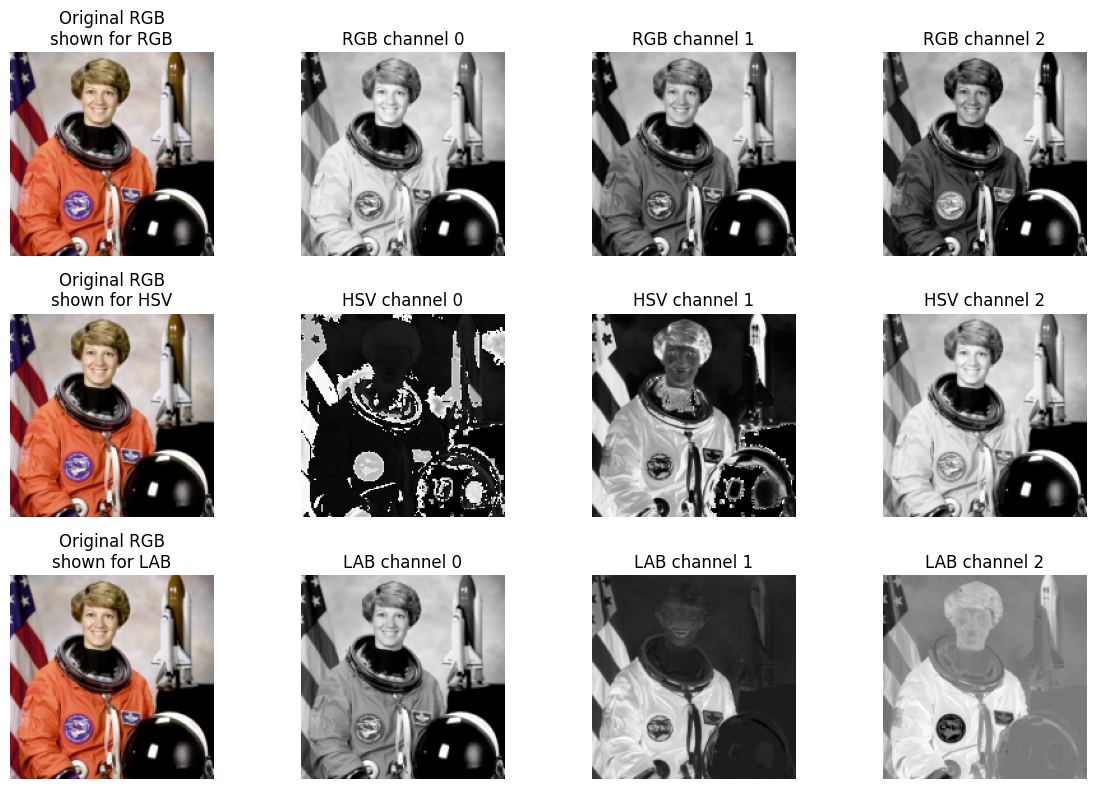

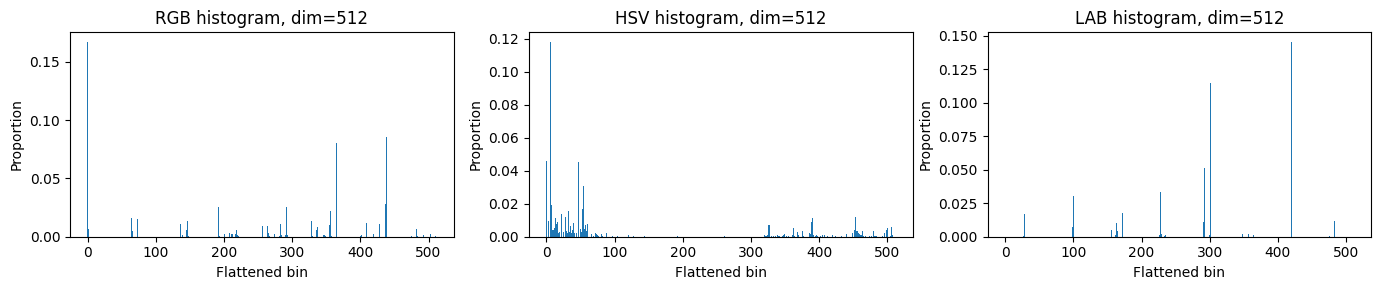

In [ ]:
sample = resize_image(data.astronaut(), size=(160, 160))
spaces = ["rgb", "hsv", "lab"]

fig, axes = plt.subplots(3, 4, figsize=(12, 8))
for row, space in enumerate(spaces):
    converted, _ = convert_color_space(sample, space=space)
    axes[row, 0].imshow(sample)
    axes[row, 0].set_title(f"Original RGB\nshown for {space.upper()}")
    axes[row, 0].axis("off")
    for ch in range(3):
        axes[row, ch+1].imshow(converted[..., ch], cmap="gray")
        axes[row, ch+1].set_title(f"{space.upper()} channel {ch}")
        axes[row, ch+1].axis("off")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, space in zip(axes, spaces):
    hist = color_histogram(sample, bins=8, space=space)
    ax.bar(np.arange(len(hist)), hist)
    ax.set_title(f"{space.upper()} histogram, dim={len(hist)}")
    ax.set_xlabel("Flattened bin")
    ax.set_ylabel("Proportion")
plt.tight_layout()
plt.show()

## 11. Similarity functions from scratch

A retrieval system needs a distance or similarity score.

For two normalized histograms \(p\) and \(q\):

### Histogram intersection
\[
S(p,q) = \sum_i \min(p_i,q_i)
\]

### Chi-square distance
\[
D_{\chi^2}(p,q) = \frac{1}{2}\sum_i \frac{(p_i-q_i)^2}{p_i+q_i+\epsilon}
\]

### Bhattacharyya distance
\[
D_B(p,q) = -\ln\left(\sum_i \sqrt{p_i q_i}\right)
\]

### Cosine similarity
\[
S(p,q) = \frac{p \cdot q}{\|p\|\|q\|}
\]

Each metric makes a different assumption about what “similar color distribution” means.

In [ ]:
EPS = 1e-12

def hist_intersection(p, q):
    """Higher is better. For L1-normalized histograms, range is usually [0, 1]."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    return float(np.minimum(p, q).sum())

def l1_distance(p, q):
    """Lower is better."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    return float(np.abs(p - q).sum())

def l2_distance(p, q):
    """Lower is better."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    return float(np.sqrt(((p - q) ** 2).sum()))

def chi_square_distance(p, q, eps=EPS):
    """Lower is better. Common for histogram comparison."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    return float(0.5 * np.sum(((p - q) ** 2) / (p + q + eps)))

def bhattacharyya_distance(p, q, eps=EPS):
    """Lower is better."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    coeff = np.sum(np.sqrt(np.maximum(p, 0) * np.maximum(q, 0)))
    return float(-np.log(coeff + eps))

def cosine_sim(p, q, eps=EPS):
    """Higher is better."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    return float(np.dot(p, q) / ((np.linalg.norm(p) * np.linalg.norm(q)) + eps))

SIMILARITY_FUNCS = {
    "intersection": {"func": hist_intersection, "higher_is_better": True},
    "cosine": {"func": cosine_sim, "higher_is_better": True},
    "l1": {"func": l1_distance, "higher_is_better": False},
    "l2": {"func": l2_distance, "higher_is_better": False},
    "chi_square": {"func": chi_square_distance, "higher_is_better": False},
    "bhattacharyya": {"func": bhattacharyya_distance, "higher_is_better": False},
}

print("Available similarity metrics:", list(SIMILARITY_FUNCS.keys()))

Available similarity metrics: ['intersection', 'cosine', 'l1', 'l2', 'chi_square', 'bhattacharyya']


## 12. White-box similarity walkthrough

Before using real images, let’s compare tiny histogram vectors.

This helps explain what each distance function is actually doing.

,bin,p,q,r,"min(p,q)",|p-q|,(p-q)^2/(p+q)
0,0,0.5,0.4,0.0,0.4,0.1,0.011111
1,1,0.3,0.4,0.1,0.3,0.1,0.014286
2,2,0.2,0.1,0.2,0.1,0.1,0.033333
3,3,0.0,0.1,0.7,0.0,0.1,0.100000


,metric,p_vs_q,p_vs_r,higher_is_better,which_is_more_similar_to_p
0,intersection,0.800000,0.300000,True,q
1,cosine,0.945905,0.154529,True,q
2,l1,0.400000,1.400000,False,q
3,l2,0.200000,0.883176,False,q
4,chi_square,0.079365,0.650000,False,q
5,bhattacharyya,0.067161,0.985627,False,q


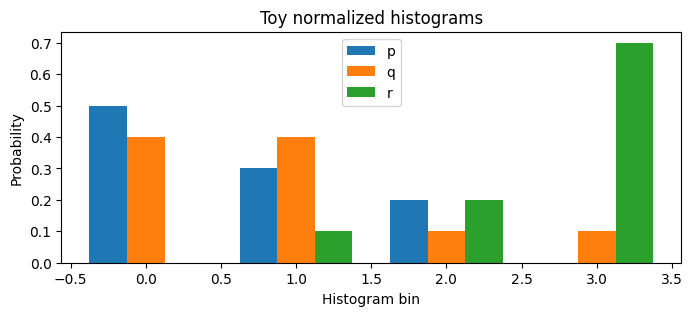

In [ ]:
p = np.array([0.50, 0.30, 0.20, 0.00])
q = np.array([0.40, 0.40, 0.10, 0.10])
r = np.array([0.00, 0.10, 0.20, 0.70])

toy_hists = pd.DataFrame({
    "bin": np.arange(len(p)),
    "p": p,
    "q": q,
    "r": r,
    "min(p,q)": np.minimum(p, q),
    "|p-q|": np.abs(p-q),
    "(p-q)^2/(p+q)": ((p-q)**2)/(p+q+EPS)
})
display(toy_hists)

score_rows = []
for name, spec in SIMILARITY_FUNCS.items():
    f = spec["func"]
    p_q = f(p, q)
    p_r = f(p, r)
    more_similar = "q" if ((spec["higher_is_better"] and p_q > p_r) or ((not spec["higher_is_better"]) and p_q < p_r)) else "r"
    score_rows.append({
        "metric": name,
        "p_vs_q": p_q,
        "p_vs_r": p_r,
        "higher_is_better": spec["higher_is_better"],
        "which_is_more_similar_to_p": more_similar
    })

display(pd.DataFrame(score_rows))

fig, ax = plt.subplots(figsize=(8, 3))
x = np.arange(len(p))
w = 0.25
ax.bar(x - w, p, width=w, label="p")
ax.bar(x, q, width=w, label="q")
ax.bar(x + w, r, width=w, label="r")
ax.set_xlabel("Histogram bin")
ax.set_ylabel("Probability")
ax.set_title("Toy normalized histograms")
ax.legend()
plt.show()

## 13. Build a small research dataset

We will use built-in `skimage` images and create controlled transformations.

Why controlled transformations?  
Because they let us ask targeted questions:

- What happens when brightness changes?
- What happens when color is shifted?
- What happens when noise or blur is added?
- Does the method retrieve variants of the same image?

In [ ]:
def adjust_brightness(img, factor=1.3):
    return np.clip(ensure_rgb(img) * factor, 0, 1)

def adjust_contrast(img, factor=1.5):
    arr = ensure_rgb(img)
    mean = arr.mean(axis=(0, 1), keepdims=True)
    return np.clip((arr - mean) * factor + mean, 0, 1)

def add_noise(img, amount=0.05):
    arr = ensure_rgb(img)
    noisy = arr + np.random.normal(0, amount, arr.shape)
    return np.clip(noisy, 0, 1)

def blur_image(img, sigma=1.5):
    return filters.gaussian(ensure_rgb(img), sigma=sigma, channel_axis=-1)

def rotate_image(img, angle=15):
    return transform.rotate(ensure_rgb(img), angle=angle, resize=False, mode="edge")

def hue_shift(img, shift=0.08):
    hsv = color.rgb2hsv(ensure_rgb(img))
    hsv[..., 0] = (hsv[..., 0] + shift) % 1.0
    return color.hsv2rgb(hsv)

base_images = {
    "astronaut": data.astronaut(),
    "coffee": data.coffee(),
    "chelsea_cat": data.chelsea(),
    "rocket": data.rocket(),
    "camera": data.camera(),
    "coins": data.coins(),
}

variants = {
    "original": lambda x: x,
    "bright": lambda x: adjust_brightness(x, 1.35),
    "dark": lambda x: adjust_brightness(x, 0.65),
    "contrast": lambda x: adjust_contrast(x, 1.6),
    "noise": lambda x: add_noise(x, 0.06),
    "blur": lambda x: blur_image(x, 1.2),
    "rotate": lambda x: rotate_image(x, 12),
    "hue_shift": lambda x: hue_shift(x, 0.08),
}

dataset = []
for label, img in base_images.items():
    for variant_name, fn in variants.items():
        dataset.append({
            "name": f"{label}_{variant_name}",
            "label": label,
            "variant": variant_name,
            "image": resize_image(fn(img), size=(128, 128))
        })

print("Dataset size:", len(dataset))
display(pd.DataFrame([{k:v for k,v in item.items() if k != "image"} for item in dataset]).head())

Dataset size: 48


,name,label,variant
0,astronaut_original,astronaut,original
1,astronaut_bright,astronaut,bright
2,astronaut_dark,astronaut,dark
3,astronaut_contrast,astronaut,contrast
4,astronaut_noise,astronaut,noise


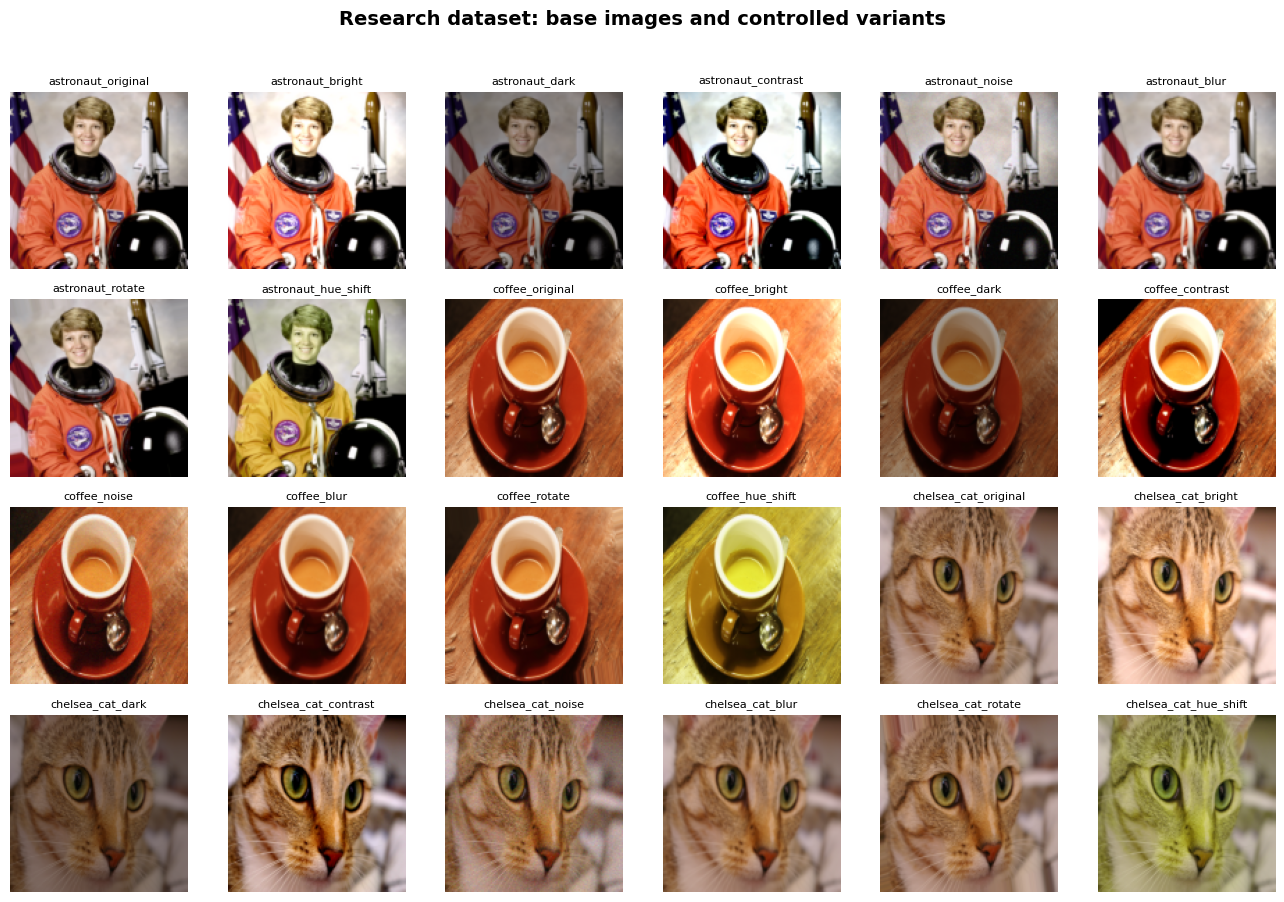

In [ ]:
def show_gallery(items, title=None, max_items=24, cols=6):
    n = min(len(items), max_items)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.2, rows*2.2))
    axes = np.array(axes).reshape(-1)
    for ax, item in zip(axes, items[:n]):
        ax.imshow(item["image"])
        ax.set_title(item["name"], fontsize=8)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    if title:
        fig.suptitle(title, y=1.02, fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

show_gallery(dataset, title="Research dataset: base images and controlled variants", max_items=24)

## 14. Retrieval pipeline

A simple CBIR pipeline has two stages.

### Offline stage
1. Load database images.
2. Extract feature vector for each image.
3. Store vectors.

### Online stage
1. Load query image.
2. Extract query feature.
3. Compare query vector to database vectors.
4. Sort by similarity.
5. Return top-k results.

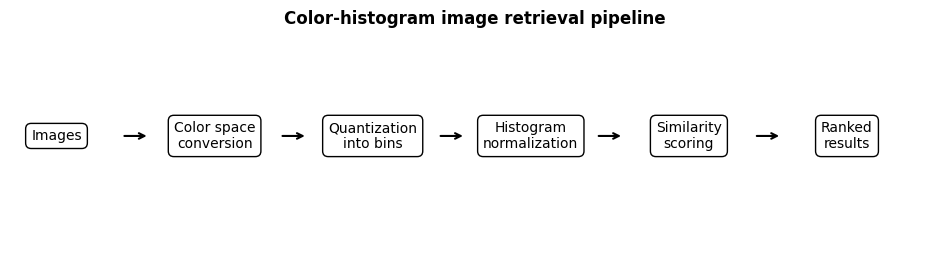

In [ ]:
def draw_retrieval_pipeline():
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis("off")
    boxes = [
        ("Images", 0.05),
        ("Color space\nconversion", 0.22),
        ("Quantization\ninto bins", 0.39),
        ("Histogram\nnormalization", 0.56),
        ("Similarity\nscoring", 0.73),
        ("Ranked\nresults", 0.90),
    ]
    for text, x in boxes:
        ax.text(x, 0.55, text, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black"))
    for (_, x1), (_, x2) in zip(boxes[:-1], boxes[1:]):
        ax.annotate("", xy=(x2-0.07, 0.55), xytext=(x1+0.07, 0.55),
                    arrowprops=dict(arrowstyle="->", lw=1.5))
    ax.set_title("Color-histogram image retrieval pipeline", weight="bold")
    plt.show()

draw_retrieval_pipeline()

## 15. Implement image retrieval

The ranking function is intentionally simple and transparent.

It returns a table with scores and image metadata.

In [ ]:
def build_feature_index(dataset, bins=8, space="rgb"):
    rows = []
    features = []
    for i, item in enumerate(dataset):
        feat = color_histogram(item["image"], bins=bins, space=space, normalize_hist=True)
        features.append(feat)
        rows.append({
            "index": i,
            "name": item["name"],
            "label": item["label"],
            "variant": item["variant"],
            "feature_dim": len(feat)
        })
    return pd.DataFrame(rows), np.vstack(features)

def rank_images(query_feature, index_df, feature_matrix, metric="intersection", exclude_index=None):
    spec = SIMILARITY_FUNCS[metric]
    func = spec["func"]
    rows = []
    for i, feat in enumerate(feature_matrix):
        if exclude_index is not None and i == exclude_index:
            continue
        score = func(query_feature, feat)
        rows.append({**index_df.iloc[i].to_dict(), "score": score})

    result = pd.DataFrame(rows)
    result = result.sort_values("score", ascending=not spec["higher_is_better"]).reset_index(drop=True)
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    return result

index_df, feature_matrix = build_feature_index(dataset, bins=8, space="hsv")
display(index_df.head())
print("Feature matrix shape:", feature_matrix.shape)

,index,name,label,variant,feature_dim
0,0,astronaut_original,astronaut,original,512
1,1,astronaut_bright,astronaut,bright,512
2,2,astronaut_dark,astronaut,dark,512
3,3,astronaut_contrast,astronaut,contrast,512
4,4,astronaut_noise,astronaut,noise,512


Feature matrix shape: (48, 512)


## 16. White-box ranking walkthrough

Let’s inspect one query:

1. show the query image,
2. show its histogram,
3. compute all database scores,
4. show the top matches.

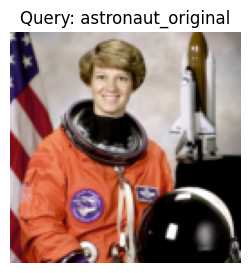

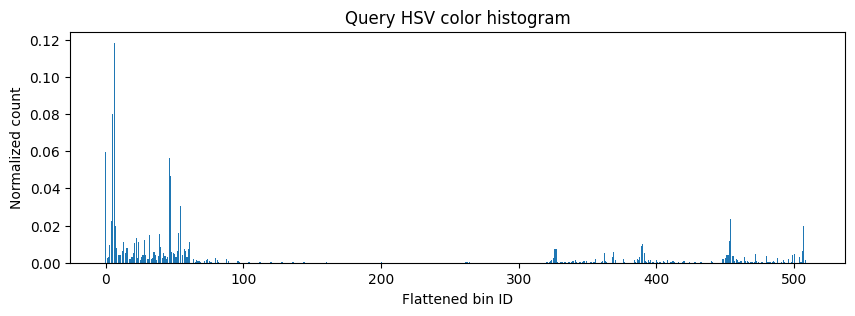

,rank,name,label,variant,score
0,1,astronaut_blur,astronaut,blur,0.947327
1,2,astronaut_rotate,astronaut,rotate,0.934021
2,3,astronaut_noise,astronaut,noise,0.797302
3,4,astronaut_hue_shift,astronaut,hue_shift,0.568726
4,5,astronaut_bright,astronaut,bright,0.507874
5,6,astronaut_dark,astronaut,dark,0.381165
6,7,coffee_contrast,coffee,contrast,0.346558
7,8,astronaut_contrast,astronaut,contrast,0.316284
8,9,chelsea_cat_contrast,chelsea_cat,contrast,0.311401
9,10,camera_original,camera,original,0.302856


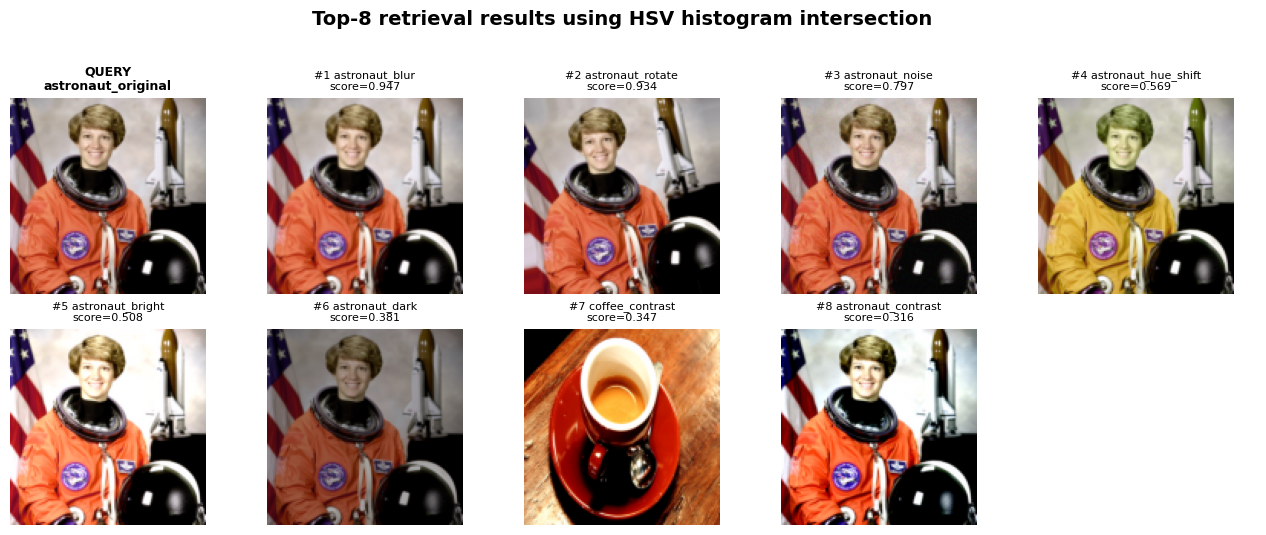

In [ ]:
def plot_histogram_vector(hist, title="Histogram vector", max_bins=None):
    if max_bins is not None:
        hist = hist[:max_bins]
    plt.figure(figsize=(10, 3))
    plt.bar(np.arange(len(hist)), hist)
    plt.xlabel("Flattened bin ID")
    plt.ylabel("Normalized count")
    plt.title(title)
    plt.show()

def show_retrieval_results(query_item, ranked_df, dataset, top_k=8, title=None):
    selected = []
    for _, row in ranked_df.head(top_k).iterrows():
        item = dataset[int(row["index"])]
        selected.append({**item, "display_title": f"#{int(row['rank'])} {row['name']}\nscore={row['score']:.3f}"})

    cols = min(top_k + 1, 5)
    rows = math.ceil((top_k + 1) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.6, rows*2.6))
    axes = np.array(axes).reshape(-1)

    axes[0].imshow(query_item["image"])
    axes[0].set_title("QUERY\n" + query_item["name"], fontsize=9, weight="bold")
    axes[0].axis("off")

    for ax, item in zip(axes[1:], selected):
        ax.imshow(item["image"])
        ax.set_title(item["display_title"], fontsize=8)
        ax.axis("off")
    for ax in axes[len(selected)+1:]:
        ax.axis("off")
    if title:
        fig.suptitle(title, y=1.02, fontsize=14, weight="bold")
    plt.tight_layout()
    plt.show()

query_idx = 0
query_item = dataset[query_idx]
query_feat = feature_matrix[query_idx]
ranked = rank_images(query_feat, index_df, feature_matrix, metric="intersection", exclude_index=query_idx)

plt.figure(figsize=(3, 3))
plt.imshow(query_item["image"])
plt.title(f"Query: {query_item['name']}")
plt.axis("off")
plt.show()

plot_histogram_vector(query_feat, title="Query HSV color histogram")

display(ranked.head(10)[["rank", "name", "label", "variant", "score"]])
show_retrieval_results(query_item, ranked, dataset, top_k=8, title="Top-8 retrieval results using HSV histogram intersection")

## 17. Evaluation metrics: Precision@K and mean Average Precision

For a controlled dataset, each transformed version keeps the same label.  
A retrieved image is relevant if it has the same base label as the query.

### Precision@K

\[
P@K = \frac{\text{relevant images in top K}}{K}
\]

### Average Precision

Average Precision rewards systems that put relevant images earlier in the ranking.

,query_index,query_name,label,variant,bins,space,metric,P@5,AP
0,0,astronaut_original,astronaut,original,8,hsv,intersection,1.0,0.982143
1,1,astronaut_bright,astronaut,bright,8,hsv,intersection,1.0,0.968254
2,2,astronaut_dark,astronaut,dark,8,hsv,intersection,0.6,0.645207
3,3,astronaut_contrast,astronaut,contrast,8,hsv,intersection,0.6,0.675850
4,4,astronaut_noise,astronaut,noise,8,hsv,intersection,1.0,0.932540


,mean_score
P@5,0.825000
AP,0.826294


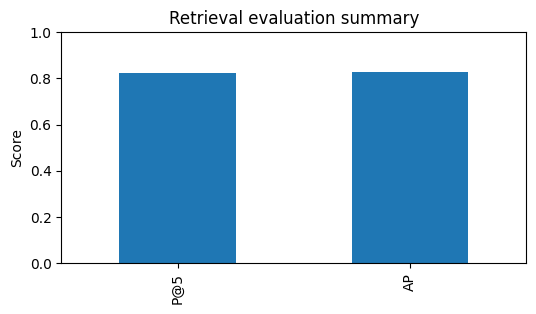

In [ ]:
def precision_at_k(ranked_df, query_label, k=5):
    top = ranked_df.head(k)
    return float((top["label"] == query_label).mean())

def average_precision(ranked_df, query_label):
    relevant = (ranked_df["label"] == query_label).values
    if relevant.sum() == 0:
        return 0.0
    precisions = []
    hits = 0
    for i, is_rel in enumerate(relevant, start=1):
        if is_rel:
            hits += 1
            precisions.append(hits / i)
    return float(np.mean(precisions))

def evaluate_retrieval(dataset, bins=8, space="hsv", metric="intersection", k=5):
    index_df, feats = build_feature_index(dataset, bins=bins, space=space)
    rows = []
    for i, item in enumerate(dataset):
        ranked = rank_images(feats[i], index_df, feats, metric=metric, exclude_index=i)
        rows.append({
            "query_index": i,
            "query_name": item["name"],
            "label": item["label"],
            "variant": item["variant"],
            "bins": bins,
            "space": space,
            "metric": metric,
            f"P@{k}": precision_at_k(ranked, item["label"], k=k),
            "AP": average_precision(ranked, item["label"])
        })
    return pd.DataFrame(rows)

eval_demo = evaluate_retrieval(dataset, bins=8, space="hsv", metric="intersection", k=5)
display(eval_demo.head())

summary_demo = eval_demo[["P@5", "AP"]].mean().to_frame("mean_score")
display(summary_demo)

plt.figure(figsize=(6, 3))
summary_demo["mean_score"].plot(kind="bar")
plt.ylim(0, 1)
plt.title("Retrieval evaluation summary")
plt.ylabel("Score")
plt.show()

## 18. Research Question 1 — Which similarity metric works best?

Color histograms can be compared in many ways.  
This experiment compares several similarity/distance functions.

,metric,mean_P@5,mean_AP
0,intersection,0.825000,0.826294
2,l1,0.825000,0.826243
4,chi_square,0.829167,0.813839
5,bhattacharyya,0.816667,0.788049
1,cosine,0.716667,0.748291
3,l2,0.637500,0.654462


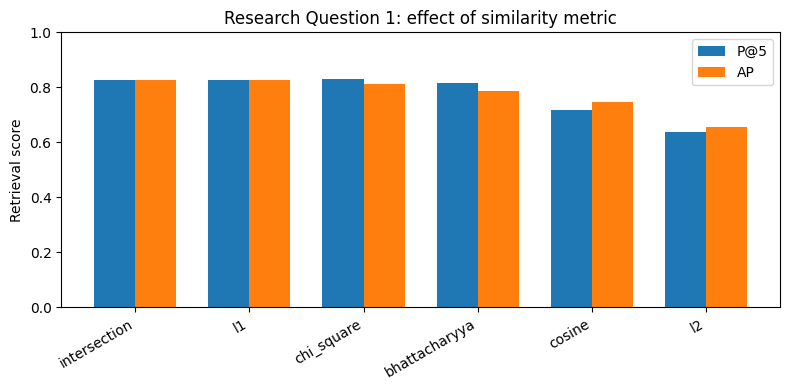

In [ ]:
metric_results = []
for metric in SIMILARITY_FUNCS.keys():
    df = evaluate_retrieval(dataset, bins=8, space="hsv", metric=metric, k=5)
    metric_results.append({
        "metric": metric,
        "mean_P@5": df["P@5"].mean(),
        "mean_AP": df["AP"].mean()
    })

metric_results = pd.DataFrame(metric_results).sort_values("mean_AP", ascending=False)
display(metric_results)

metric_results.to_csv(OUTPUT_DIR / "color_hist_metric_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(metric_results))
ax.bar(x - 0.18, metric_results["mean_P@5"], width=0.36, label="P@5")
ax.bar(x + 0.18, metric_results["mean_AP"], width=0.36, label="AP")
ax.set_xticks(x)
ax.set_xticklabels(metric_results["metric"], rotation=30, ha="right")
ax.set_ylim(0, 1)
ax.set_title("Research Question 1: effect of similarity metric")
ax.set_ylabel("Retrieval score")
ax.legend()
plt.tight_layout()
plt.show()

## 19. Research Question 2 — Which color space is better?

RGB, HSV, and Lab encode colors differently.

This experiment asks:

> Does the same histogram method behave differently across color spaces?

,space,metric,mean_P@5,mean_AP
0,rgb,intersection,0.866667,0.866644
1,rgb,chi_square,0.858333,0.852601
2,rgb,bhattacharyya,0.837500,0.829751
4,hsv,intersection,0.825000,0.826294
5,hsv,chi_square,0.829167,0.813839
3,rgb,cosine,0.783333,0.797436
8,lab,intersection,0.812500,0.792077
6,hsv,bhattacharyya,0.816667,0.788049
9,lab,chi_square,0.783333,0.774324
10,lab,bhattacharyya,0.766667,0.754777


space,hsv,lab,rgb
metric,,,
bhattacharyya,0.788049,0.754777,0.829751
chi_square,0.813839,0.774324,0.852601
cosine,0.748291,0.747062,0.797436
intersection,0.826294,0.792077,0.866644


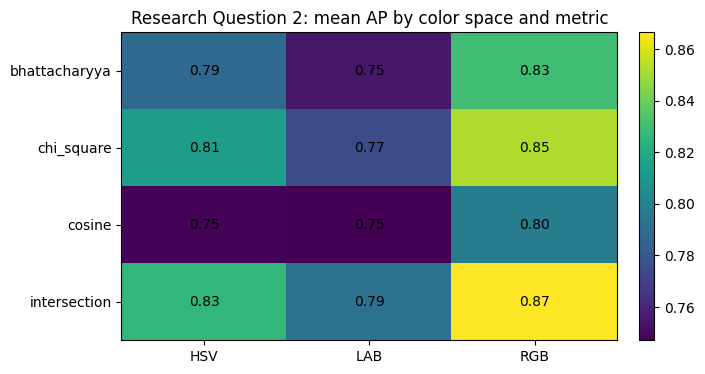

In [ ]:
space_results = []
for space in ["rgb", "hsv", "lab"]:
    for metric in ["intersection", "chi_square", "bhattacharyya", "cosine"]:
        df = evaluate_retrieval(dataset, bins=8, space=space, metric=metric, k=5)
        space_results.append({
            "space": space,
            "metric": metric,
            "mean_P@5": df["P@5"].mean(),
            "mean_AP": df["AP"].mean()
        })

space_results = pd.DataFrame(space_results).sort_values("mean_AP", ascending=False)
display(space_results)

space_results.to_csv(OUTPUT_DIR / "color_hist_color_space_study.csv", index=False)

pivot = space_results.pivot(index="metric", columns="space", values="mean_AP")
display(pivot)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot.values, aspect="auto")
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels([c.upper() for c in pivot.columns])
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center")
ax.set_title("Research Question 2: mean AP by color space and metric")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## 20. Research Question 3 — How many bins should we use?

More bins produce a more detailed descriptor, but also:

- higher dimensionality,
- more sparse vectors,
- more sensitivity to noise and illumination,
- more memory cost.

For \(b\) bins per channel:

\[
\text{dimension} = b^3
\]

,bins_per_channel,descriptor_dim,mean_P@5,mean_AP,average_sparsity_fraction
0,2,8,0.875000,0.840635,0.317708
1,4,64,0.862500,0.837946,0.635742
2,8,512,0.825000,0.826294,0.802043
3,12,1728,0.841667,0.799558,0.862582
4,16,4096,0.829167,0.786388,0.896795
5,24,13824,0.812500,0.782389,0.934438
6,32,32768,0.808333,0.781505,0.955966


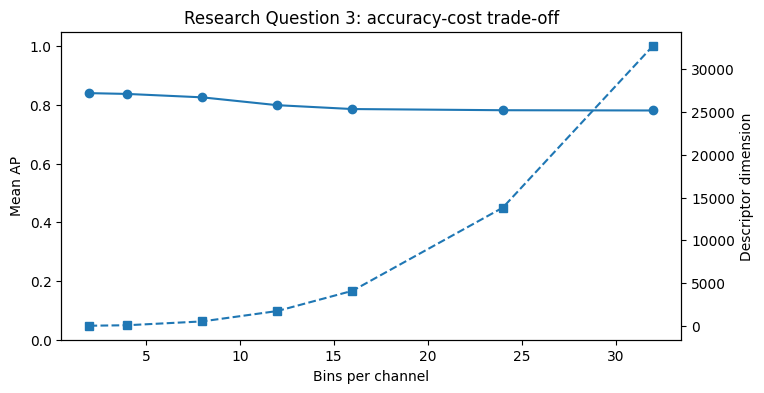

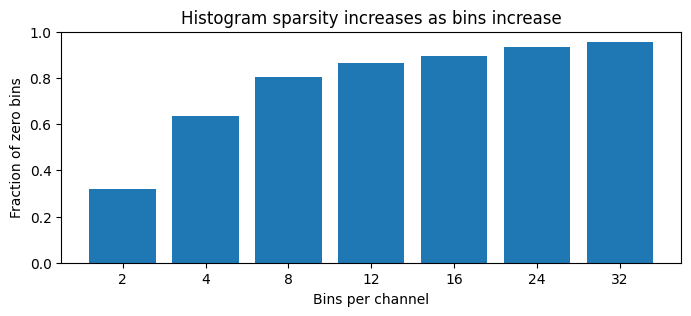

In [ ]:
bin_results = []
for bins in [2, 4, 8, 12, 16, 24, 32]:
    df = evaluate_retrieval(dataset, bins=bins, space="hsv", metric="intersection", k=5)
    dim = bins ** 3
    _, feats = build_feature_index(dataset, bins=bins, space="hsv")
    sparsity = float((feats == 0).mean())
    bin_results.append({
        "bins_per_channel": bins,
        "descriptor_dim": dim,
        "mean_P@5": df["P@5"].mean(),
        "mean_AP": df["AP"].mean(),
        "average_sparsity_fraction": sparsity
    })

bin_results = pd.DataFrame(bin_results)
display(bin_results)

bin_results.to_csv(OUTPUT_DIR / "color_hist_bin_sensitivity.csv", index=False)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(bin_results["bins_per_channel"], bin_results["mean_AP"], marker="o", label="mean AP")
ax1.set_xlabel("Bins per channel")
ax1.set_ylabel("Mean AP")
ax1.set_ylim(0, 1.05)
ax2 = ax1.twinx()
ax2.plot(bin_results["bins_per_channel"], bin_results["descriptor_dim"], marker="s", linestyle="--", label="dimension")
ax2.set_ylabel("Descriptor dimension")
ax1.set_title("Research Question 3: accuracy-cost trade-off")
plt.show()

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(bin_results["bins_per_channel"].astype(str), bin_results["average_sparsity_fraction"])
ax.set_ylim(0, 1)
ax.set_xlabel("Bins per channel")
ax.set_ylabel("Fraction of zero bins")
ax.set_title("Histogram sparsity increases as bins increase")
plt.show()

## 21. Research Question 4 — Robustness to image transformations

Color histograms ignore exact pixel position, so they are often robust to rotation and small geometric changes.

But they are sensitive to color shifts and illumination changes.

We test this by comparing one original image against its transformed versions.

,transformation,score
0,original,1.000000
5,blur,0.985718
6,rotate,0.944824
4,noise,0.873230
3,contrast,0.657959
1,bright,0.411743
7,hue_shift,0.347473
2,dark,0.267395


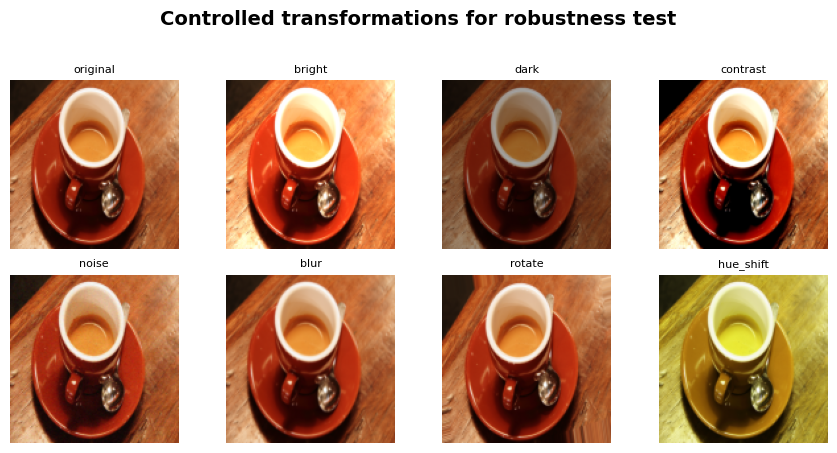

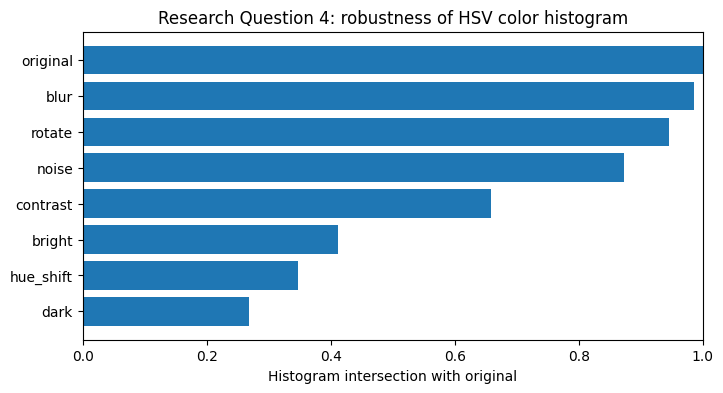

In [ ]:
def compare_transform_robustness(base_img, bins=8, space="hsv", metric="intersection"):
    base = resize_image(base_img)
    base_feat = color_histogram(base, bins=bins, space=space)
    rows = []
    images = []
    for name, fn in variants.items():
        transformed_img = resize_image(fn(base_img))
        feat = color_histogram(transformed_img, bins=bins, space=space)
        score = SIMILARITY_FUNCS[metric]["func"](base_feat, feat)
        rows.append({"transformation": name, "score": score})
        images.append({"name": name, "image": transformed_img})
    return pd.DataFrame(rows), images

robust_df, robust_images = compare_transform_robustness(data.coffee(), bins=8, space="hsv", metric="intersection")
display(robust_df.sort_values("score", ascending=False))

robust_df.to_csv(OUTPUT_DIR / "color_hist_robustness_study.csv", index=False)

show_gallery(robust_images, title="Controlled transformations for robustness test", max_items=len(robust_images), cols=4)

plt.figure(figsize=(8, 4))
ordered = robust_df.sort_values("score", ascending=True)
plt.barh(ordered["transformation"], ordered["score"])
plt.xlabel("Histogram intersection with original")
plt.title("Research Question 4: robustness of HSV color histogram")
plt.xlim(0, 1)
plt.show()

## 22. Research Question 5 — Does spatial layout matter?

A **global color histogram** ignores where colors occur.

Two images can have exactly the same colors but different arrangements.  
The global histogram says they are the same.

This is not a bug in code; it is a limitation of the descriptor.

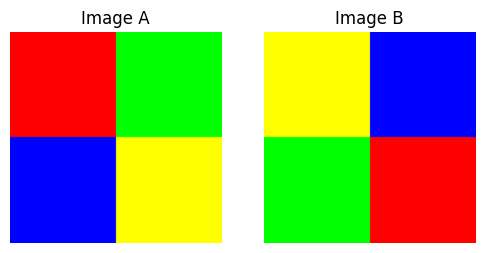

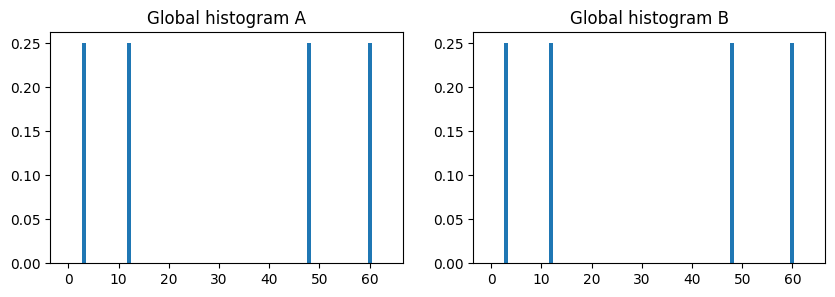

Histogram intersection: 1.0
Max absolute difference: 0.0


In [ ]:
def make_layout_pair(size=128):
    img_a = np.zeros((size, size, 3), dtype=float)
    img_b = np.zeros((size, size, 3), dtype=float)

    half = size // 2
    img_a[:half, :half] = [1, 0, 0]
    img_a[:half, half:] = [0, 1, 0]
    img_a[half:, :half] = [0, 0, 1]
    img_a[half:, half:] = [1, 1, 0]

    img_b[:half, :half] = [1, 1, 0]
    img_b[:half, half:] = [0, 0, 1]
    img_b[half:, :half] = [0, 1, 0]
    img_b[half:, half:] = [1, 0, 0]
    return img_a, img_b

layout_a, layout_b = make_layout_pair()

hist_a = color_histogram(layout_a, bins=4, space="rgb")
hist_b = color_histogram(layout_b, bins=4, space="rgb")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(layout_a); axes[0].set_title("Image A"); axes[0].axis("off")
axes[1].imshow(layout_b); axes[1].set_title("Image B"); axes[1].axis("off")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].bar(np.arange(len(hist_a)), hist_a)
axes[0].set_title("Global histogram A")
axes[1].bar(np.arange(len(hist_b)), hist_b)
axes[1].set_title("Global histogram B")
plt.show()

print("Histogram intersection:", hist_intersection(hist_a, hist_b))
print("Max absolute difference:", np.max(np.abs(hist_a - hist_b)))

## 23. Fixing the layout problem: spatial color histograms

A simple improvement is to divide the image into a grid and compute one histogram per cell.

For a \(g \times g\) grid and histogram dimension \(d\):

\[
\text{spatial descriptor dimension} = g^2 \times d
\]

This keeps coarse spatial layout while remaining simple.

Global histogram intersection: 1.0
Spatial histogram intersection: 0.0
Global dim: 64
Spatial dim: 256


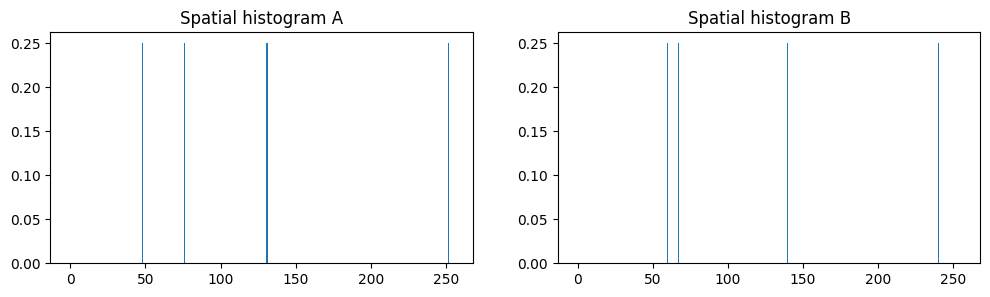

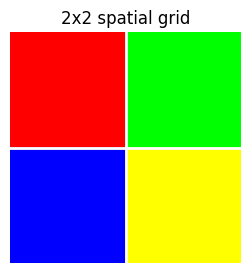

In [ ]:
def spatial_color_histogram(image, bins=4, space="rgb", grid=(2, 2)):
    """
    Spatial color histogram:
    1. Split image into grid cells.
    2. Compute color histogram per cell.
    3. Concatenate all cell histograms.
    """
    img = resize_image(image, size=(128, 128))
    h, w = img.shape[:2]
    gh, gw = grid
    features = []
    for gy in range(gh):
        for gx in range(gw):
            y0, y1 = int(gy*h/gh), int((gy+1)*h/gh)
            x0, x1 = int(gx*w/gw), int((gx+1)*w/gw)
            cell = img[y0:y1, x0:x1]
            features.append(color_histogram(cell, bins=bins, space=space, normalize_hist=True))
    feat = np.concatenate(features)
    if feat.sum() > 0:
        feat = feat / feat.sum()
    return feat

spatial_a = spatial_color_histogram(layout_a, bins=4, space="rgb", grid=(2, 2))
spatial_b = spatial_color_histogram(layout_b, bins=4, space="rgb", grid=(2, 2))

print("Global histogram intersection:", hist_intersection(hist_a, hist_b))
print("Spatial histogram intersection:", hist_intersection(spatial_a, spatial_b))
print("Global dim:", len(hist_a))
print("Spatial dim:", len(spatial_a))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].bar(np.arange(len(spatial_a)), spatial_a)
axes[0].set_title("Spatial histogram A")
axes[1].bar(np.arange(len(spatial_b)), spatial_b)
axes[1].set_title("Spatial histogram B")
plt.show()

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(layout_a)
ax.axhline(layout_a.shape[0]//2, color="white", linewidth=2)
ax.axvline(layout_a.shape[1]//2, color="white", linewidth=2)
ax.set_title("2x2 spatial grid")
ax.axis("off")
plt.show()

## 24. Spatial histogram retrieval experiment

Now we evaluate whether spatial histograms improve retrieval on the controlled dataset.

The answer depends on the dataset.  
If class identity is mostly color, global histograms can be strong.  
If layout matters, spatial histograms help.

,descriptor,feature_dim,mean_P@5,mean_AP
0,Global HSV histogram,512,0.825000,0.826294
1,2x2 spatial HSV histogram,256,0.945833,0.903981


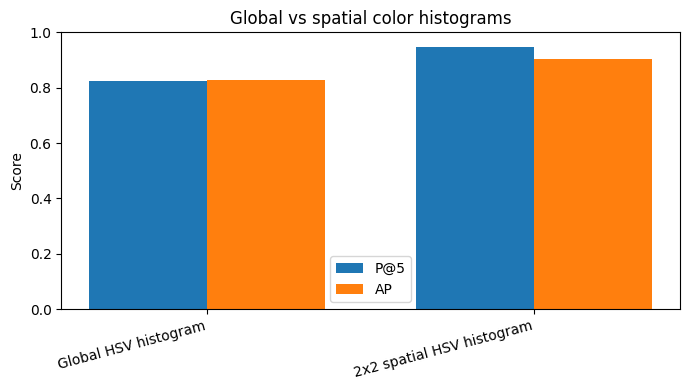

In [ ]:
def build_spatial_feature_index(dataset, bins=4, space="hsv", grid=(2, 2)):
    rows, features = [], []
    for i, item in enumerate(dataset):
        feat = spatial_color_histogram(item["image"], bins=bins, space=space, grid=grid)
        features.append(feat)
        rows.append({
            "index": i,
            "name": item["name"],
            "label": item["label"],
            "variant": item["variant"],
            "feature_dim": len(feat)
        })
    return pd.DataFrame(rows), np.vstack(features)

def evaluate_with_custom_features(dataset, index_df, feats, metric="intersection", k=5):
    rows = []
    for i, item in enumerate(dataset):
        ranked = rank_images(feats[i], index_df, feats, metric=metric, exclude_index=i)
        rows.append({
            "query_index": i,
            "query_name": item["name"],
            "label": item["label"],
            "variant": item["variant"],
            f"P@{k}": precision_at_k(ranked, item["label"], k=k),
            "AP": average_precision(ranked, item["label"])
        })
    return pd.DataFrame(rows)

global_index, global_feats = build_feature_index(dataset, bins=8, space="hsv")
spatial_index, spatial_feats = build_spatial_feature_index(dataset, bins=4, space="hsv", grid=(2, 2))

global_eval = evaluate_with_custom_features(dataset, global_index, global_feats, metric="intersection", k=5)
spatial_eval = evaluate_with_custom_features(dataset, spatial_index, spatial_feats, metric="intersection", k=5)

spatial_compare = pd.DataFrame([
    {"descriptor": "Global HSV histogram", "feature_dim": global_feats.shape[1], "mean_P@5": global_eval["P@5"].mean(), "mean_AP": global_eval["AP"].mean()},
    {"descriptor": "2x2 spatial HSV histogram", "feature_dim": spatial_feats.shape[1], "mean_P@5": spatial_eval["P@5"].mean(), "mean_AP": spatial_eval["AP"].mean()},
])
display(spatial_compare)

spatial_compare.to_csv(OUTPUT_DIR / "color_hist_global_vs_spatial.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(spatial_compare))
ax.bar(x - 0.18, spatial_compare["mean_P@5"], width=0.36, label="P@5")
ax.bar(x + 0.18, spatial_compare["mean_AP"], width=0.36, label="AP")
ax.set_xticks(x)
ax.set_xticklabels(spatial_compare["descriptor"], rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Global vs spatial color histograms")
ax.legend()
plt.tight_layout()
plt.show()

## 25. Color layout descriptor idea

MPEG-7 includes color-layout style descriptors: instead of counting all colors globally, summarize **where representative colors occur**.

Here we implement a simplified version:

1. split image into a grid,
2. compute average color per grid cell,
3. flatten the grid into a compact descriptor.

This is not the full MPEG-7 standard, but it demonstrates the core idea.

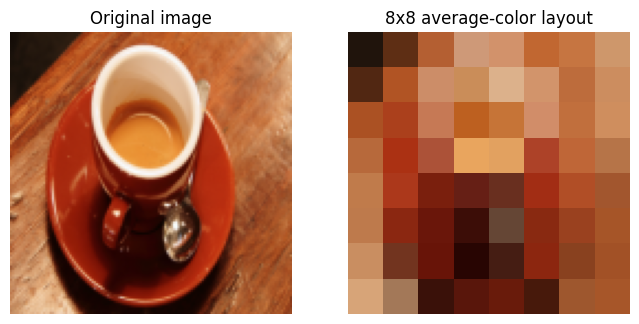

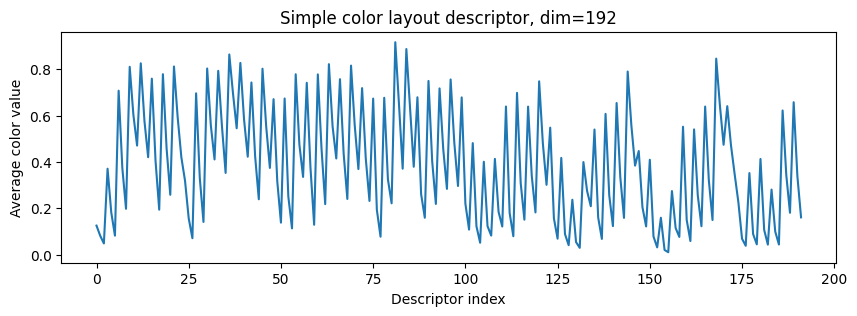

In [ ]:
def simple_color_layout_descriptor(image, grid=(8, 8), space="rgb"):
    """
    Simplified color layout descriptor:
    average color per grid cell, flattened.
    """
    img = resize_image(image, size=(128, 128))
    converted, _ = convert_color_space(img, space=space)
    h, w = converted.shape[:2]
    gh, gw = grid
    desc = []
    layout = np.zeros((gh, gw, 3), dtype=float)
    for gy in range(gh):
        for gx in range(gw):
            y0, y1 = int(gy*h/gh), int((gy+1)*h/gh)
            x0, x1 = int(gx*w/gw), int((gx+1)*w/gw)
            mean_color = converted[y0:y1, x0:x1].mean(axis=(0, 1))
            layout[gy, gx] = mean_color
            desc.extend(mean_color)
    return np.asarray(desc, dtype=float), layout

desc, layout = simple_color_layout_descriptor(data.coffee(), grid=(8, 8), space="rgb")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(resize_image(data.coffee()))
axes[0].set_title("Original image")
axes[0].axis("off")
axes[1].imshow(np.clip(layout, 0, 1))
axes[1].set_title("8x8 average-color layout")
axes[1].axis("off")
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(desc)
plt.title(f"Simple color layout descriptor, dim={len(desc)}")
plt.xlabel("Descriptor index")
plt.ylabel("Average color value")
plt.show()

## 26. Synthetic failure-case dataset

To prove the point more clearly, we create images where:

- some have the same global colors but different layout,
- some have similar layout but different colors,
- some have same color and same layout.

This lets us test whether global histogram, spatial histogram, and color layout behave differently.

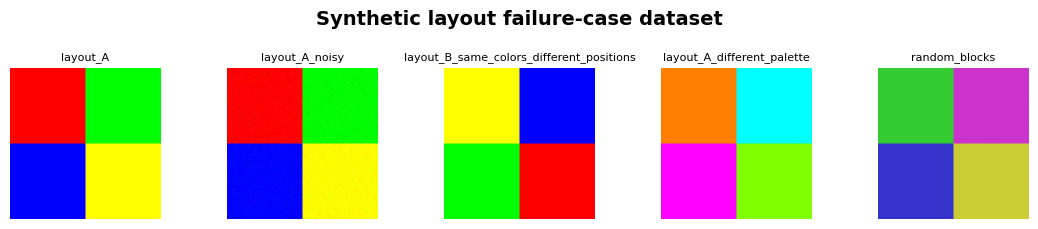

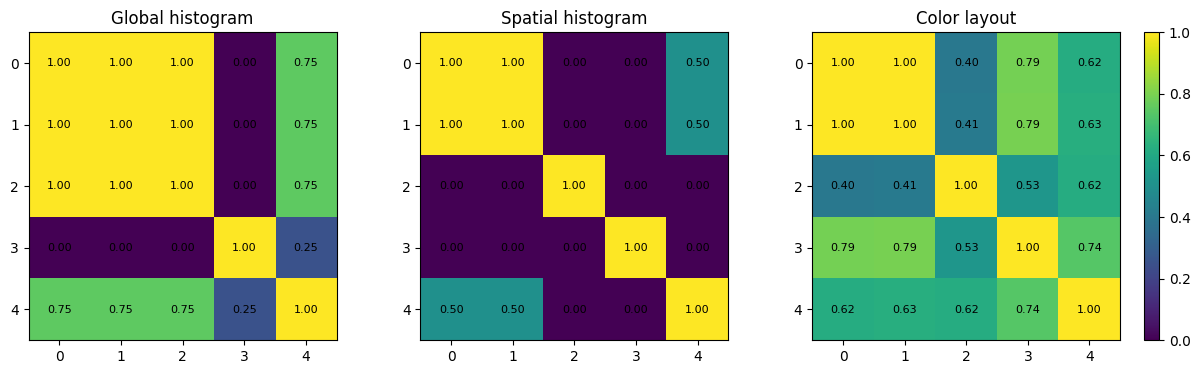

,id,name
0,0,layout_A
1,1,layout_A_noisy
2,2,layout_B_same_colors_different_positions
3,3,layout_A_different_palette
4,4,random_blocks


In [ ]:
def synthetic_layout_dataset(size=128):
    images = []
    base_a, base_b = make_layout_pair(size=size)

    noisy_a = np.clip(base_a + np.random.normal(0, 0.03, base_a.shape), 0, 1)

    palette_shift = np.zeros_like(base_a)
    half = size // 2
    palette_shift[:half, :half] = [1, 0.5, 0]
    palette_shift[:half, half:] = [0, 1, 1]
    palette_shift[half:, :half] = [1, 0, 1]
    palette_shift[half:, half:] = [0.5, 1, 0]

    random_blocks = np.zeros_like(base_a)
    block_colors = [[0.2,0.8,0.2], [0.8,0.2,0.8], [0.2,0.2,0.8], [0.8,0.8,0.2]]
    random_blocks[:half, :half] = block_colors[0]
    random_blocks[:half, half:] = block_colors[1]
    random_blocks[half:, :half] = block_colors[2]
    random_blocks[half:, half:] = block_colors[3]

    for name, label, img in [
        ("layout_A", "A", base_a),
        ("layout_A_noisy", "A", noisy_a),
        ("layout_B_same_colors_different_positions", "B", base_b),
        ("layout_A_different_palette", "C", palette_shift),
        ("random_blocks", "D", random_blocks),
    ]:
        images.append({"name": name, "label": label, "variant": "synthetic", "image": img})
    return images

syn = synthetic_layout_dataset()
show_gallery(syn, title="Synthetic layout failure-case dataset", max_items=5, cols=5)

def pairwise_similarity_matrix(items, feature_fn, metric="intersection"):
    feats = np.vstack([feature_fn(item["image"]) for item in items])
    mat = np.zeros((len(items), len(items)))
    for i in range(len(items)):
        for j in range(len(items)):
            mat[i, j] = SIMILARITY_FUNCS[metric]["func"](feats[i], feats[j])
    return mat

global_mat = pairwise_similarity_matrix(syn, lambda img: color_histogram(img, bins=4, space="rgb"), metric="intersection")
spatial_mat = pairwise_similarity_matrix(syn, lambda img: spatial_color_histogram(img, bins=4, space="rgb", grid=(2,2)), metric="intersection")
layout_mat = pairwise_similarity_matrix(syn, lambda img: simple_color_layout_descriptor(img, grid=(2,2), space="rgb")[0], metric="cosine")

names = [item["name"] for item in syn]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, mat, title in zip(axes, [global_mat, spatial_mat, layout_mat], ["Global histogram", "Spatial histogram", "Color layout"]):
    im = ax.imshow(mat, vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(range(len(names)))
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(range(len(names)))
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
plt.show()

display(pd.DataFrame({"id": range(len(names)), "name": names}))

## 27. Research Question 6 — Can color histograms be fused with shape/texture?

Color alone cannot represent shape.  
A common practical strategy is feature fusion:

\[
\text{combined distance} = \alpha D_\text{color} + (1-\alpha)D_\text{shape/texture}
\]

Here we fuse color with a small HOG descriptor to demonstrate the idea.

,alpha_color_weight,mean_P@5,mean_AP,feature_dim
0,0.0,1.000000,0.999628,2276
1,0.2,1.000000,1.000000,2276
2,0.4,0.991667,0.990754,2276
3,0.6,0.870833,0.861364,2276
4,0.8,0.733333,0.766634,2276
5,1.0,0.716667,0.748291,2276


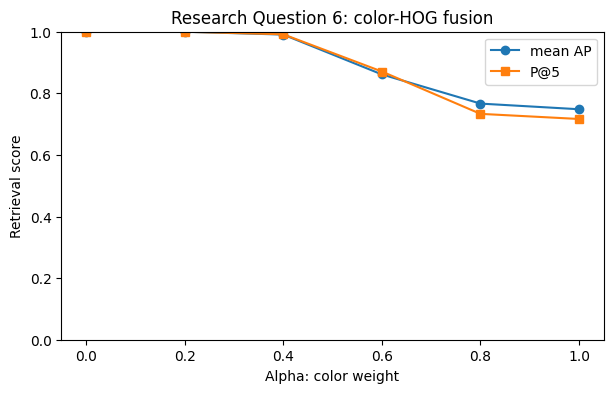

In [ ]:
def hog_descriptor(image):
    img = resize_image(image, size=(128, 128))
    gray = color.rgb2gray(img)
    feat = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=False,
        feature_vector=True
    )
    norm = np.linalg.norm(feat)
    if norm > 0:
        feat = feat / norm
    return feat

def fused_descriptor(image, color_bins=8, color_space="hsv", alpha=0.5):
    ch = color_histogram(image, bins=color_bins, space=color_space)
    hg = hog_descriptor(image)
    ch = ch / (np.linalg.norm(ch) + EPS)
    hg = hg / (np.linalg.norm(hg) + EPS)
    return np.concatenate([alpha * ch, (1 - alpha) * hg])

fusion_rows = []
for alpha in np.linspace(0, 1, 6):
    rows, feats = [], []
    for i, item in enumerate(dataset):
        feats.append(fused_descriptor(item["image"], color_bins=8, color_space="hsv", alpha=alpha))
        rows.append({"index": i, "name": item["name"], "label": item["label"], "variant": item["variant"], "feature_dim": len(feats[-1])})
    idx = pd.DataFrame(rows)
    feats = np.vstack(feats)
    df = evaluate_with_custom_features(dataset, idx, feats, metric="cosine", k=5)
    fusion_rows.append({
        "alpha_color_weight": alpha,
        "mean_P@5": df["P@5"].mean(),
        "mean_AP": df["AP"].mean(),
        "feature_dim": feats.shape[1]
    })

fusion_df = pd.DataFrame(fusion_rows)
display(fusion_df)

fusion_df.to_csv(OUTPUT_DIR / "color_hist_hog_fusion_study.csv", index=False)

plt.figure(figsize=(7, 4))
plt.plot(fusion_df["alpha_color_weight"], fusion_df["mean_AP"], marker="o", label="mean AP")
plt.plot(fusion_df["alpha_color_weight"], fusion_df["mean_P@5"], marker="s", label="P@5")
plt.xlabel("Alpha: color weight")
plt.ylabel("Retrieval score")
plt.ylim(0, 1)
plt.title("Research Question 6: color-HOG fusion")
plt.legend()
plt.show()

## 28. How to inspect function behavior on your own image

This diagnostic cell is useful for reports and debugging.

It shows:

- image,
- color-space channels,
- histogram,
- top bins,
- retrieval results.

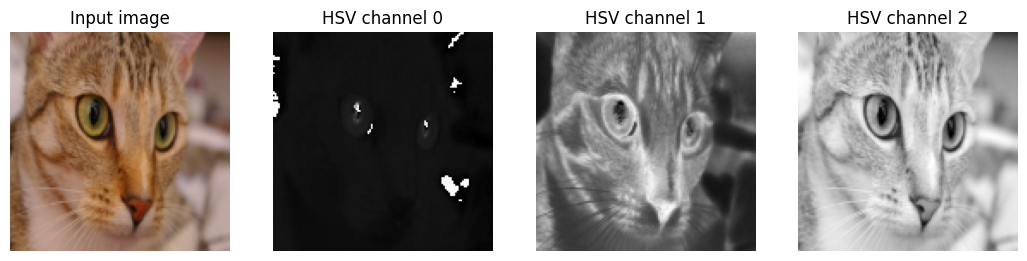

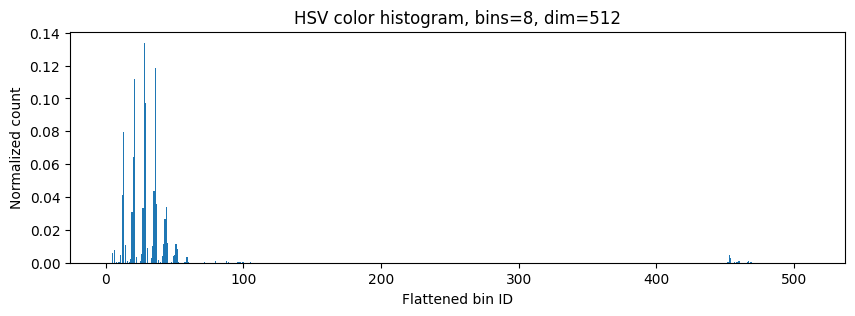

,rank,flat_bin_id,hist_value
0,1,28,0.133911
1,2,36,0.118591
2,3,21,0.112061
3,4,29,0.097290
4,5,13,0.079468
5,6,20,0.064209
6,7,35,0.043701
7,8,12,0.041382
8,9,37,0.035950
9,10,44,0.034119


In [ ]:
def explain_color_histogram(image, bins=8, space="hsv", top_n=10):
    """
    Diagnostic function to explain what the color histogram is doing.
    """
    img = resize_image(image, size=(128, 128))
    converted, ranges = convert_color_space(img, space=space)
    hist = color_histogram(img, bins=bins, space=space)

    fig, axes = plt.subplots(1, 4, figsize=(13, 3))
    axes[0].imshow(img)
    axes[0].set_title("Input image")
    axes[0].axis("off")
    for ch in range(3):
        axes[ch+1].imshow(converted[..., ch], cmap="gray")
        axes[ch+1].set_title(f"{space.upper()} channel {ch}")
        axes[ch+1].axis("off")
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.bar(np.arange(len(hist)), hist)
    plt.title(f"{space.upper()} color histogram, bins={bins}, dim={len(hist)}")
    plt.xlabel("Flattened bin ID")
    plt.ylabel("Normalized count")
    plt.show()

    top_ids = np.argsort(hist)[::-1][:top_n]
    top_df = pd.DataFrame({
        "rank": np.arange(1, top_n + 1),
        "flat_bin_id": top_ids,
        "hist_value": hist[top_ids]
    })
    display(top_df)
    return hist, top_df

_ = explain_color_histogram(data.chelsea(), bins=8, space="hsv", top_n=10)

## 29. Retrieval diagnostic function

This function exposes the whole retrieval process in one call.

Use it as a report demo cell.

### Query: `coffee_original`

- Color space: **HSV**
- Bins per channel: **8**
- Metric: **intersection**
- Feature dimension: **512**

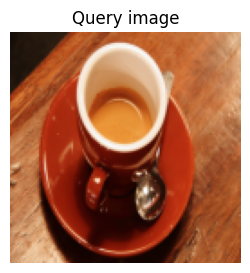

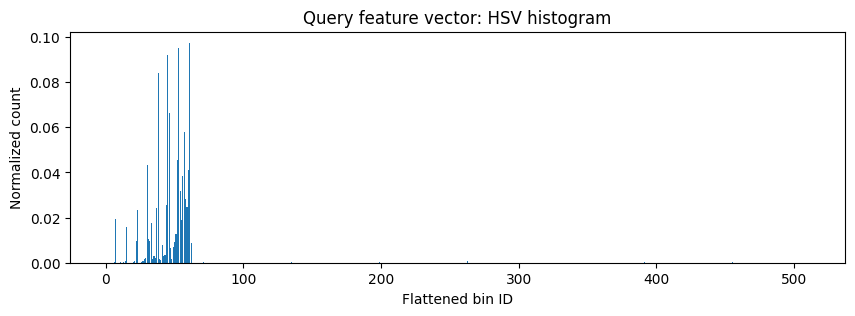

,rank,name,label,variant,score
0,1,coffee_blur,coffee,blur,0.985718
1,2,coffee_rotate,coffee,rotate,0.944824
2,3,coffee_noise,coffee,noise,0.870789
3,4,coffee_contrast,coffee,contrast,0.657959
4,5,coffee_bright,coffee,bright,0.411743
5,6,chelsea_cat_bright,chelsea_cat,bright,0.349426
6,7,coffee_hue_shift,coffee,hue_shift,0.347473
7,8,chelsea_cat_contrast,chelsea_cat,contrast,0.284119


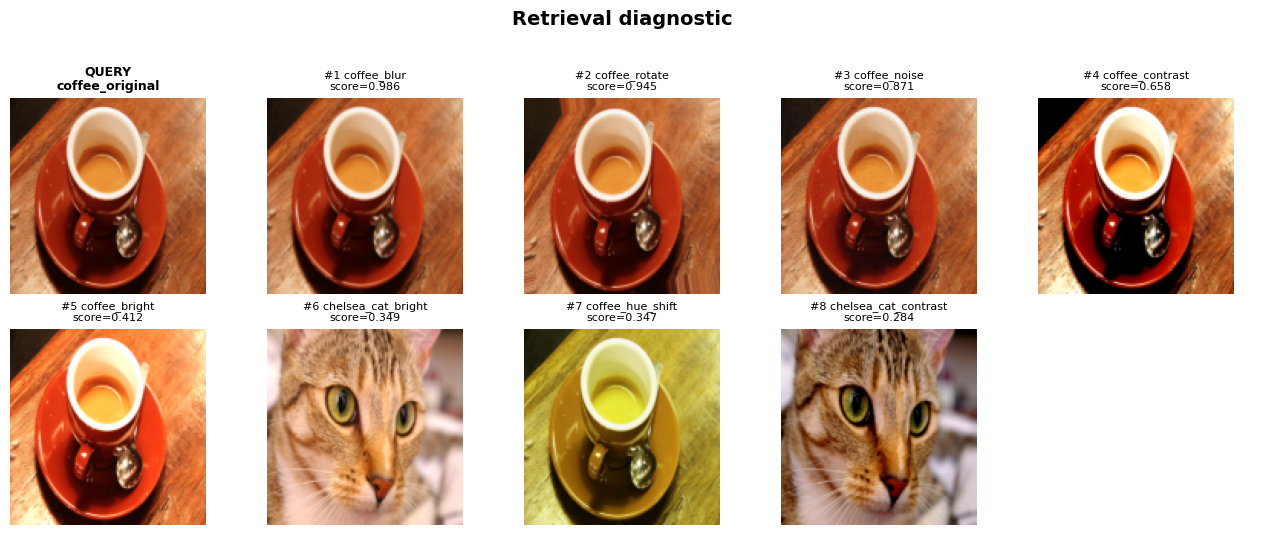

In [ ]:
def explain_retrieval(query_index=0, bins=8, space="hsv", metric="intersection", top_k=8):
    index_df, feats = build_feature_index(dataset, bins=bins, space=space)
    query_item = dataset[query_index]
    query_feat = feats[query_index]
    ranked = rank_images(query_feat, index_df, feats, metric=metric, exclude_index=query_index)

    display(Markdown(f"### Query: `{query_item['name']}`"))
    display(Markdown(f"- Color space: **{space.upper()}**\n- Bins per channel: **{bins}**\n- Metric: **{metric}**\n- Feature dimension: **{len(query_feat)}**"))

    plt.figure(figsize=(3, 3))
    plt.imshow(query_item["image"])
    plt.title("Query image")
    plt.axis("off")
    plt.show()

    plot_histogram_vector(query_feat, title=f"Query feature vector: {space.upper()} histogram")

    display(ranked.head(top_k)[["rank", "name", "label", "variant", "score"]])
    show_retrieval_results(query_item, ranked, dataset, top_k=top_k, title="Retrieval diagnostic")
    return ranked

ranked_example = explain_retrieval(query_index=8, bins=8, space="hsv", metric="intersection", top_k=8)

## 30. Research question checklist for your report

You can turn these into slides or a mini-research report.

| Research question | Experiment in this notebook | Expected discussion |
|---|---|---|
| Which similarity metric works best? | Metric comparison table and bar chart | Histogram intersection and chi-square are common choices, but results depend on dataset. |
| Which color space works best? | RGB/HSV/Lab comparison | HSV can separate hue from brightness; Lab can be perceptual; no universal winner. |
| How many bins are enough? | Bin sensitivity + sparsity plots | More bins increase detail and dimensionality but may overfit/noise. |
| Is the method robust to transformations? | Brightness/noise/blur/rotation/hue shift stress test | Position changes are okay; color shifts are dangerous. |
| Does spatial layout matter? | Same-color different-layout synthetic pair | Global histograms fail because they ignore location. |
| Can we improve with spatial features? | Spatial histogram and color layout descriptors | Coarse layout helps but increases dimension. |
| Can color be fused with texture/shape? | Color + HOG fusion | Fusion reduces single-feature blind spots. |

In [ ]:
research_questions = pd.DataFrame([
    {"RQ": "RQ1", "question": "Which similarity metric is best for color histograms?", "evidence_file": "color_hist_metric_comparison.csv"},
    {"RQ": "RQ2", "question": "How does color space affect retrieval?", "evidence_file": "color_hist_color_space_study.csv"},
    {"RQ": "RQ3", "question": "What is the bin-count trade-off?", "evidence_file": "color_hist_bin_sensitivity.csv"},
    {"RQ": "RQ4", "question": "How robust are color histograms to transformations?", "evidence_file": "color_hist_robustness_study.csv"},
    {"RQ": "RQ5", "question": "Why does spatial layout matter?", "evidence_file": "color_hist_global_vs_spatial.csv"},
    {"RQ": "RQ6", "question": "Does fusion with HOG improve retrieval?", "evidence_file": "color_hist_hog_fusion_study.csv"},
])
display(research_questions)

research_questions.to_csv(OUTPUT_DIR / "color_hist_research_questions.csv", index=False)

,RQ,question,evidence_file
0,RQ1,Which similarity metric is best for color hist...,color_hist_metric_comparison.csv
1,RQ2,How does color space affect retrieval?,color_hist_color_space_study.csv
2,RQ3,What is the bin-count trade-off?,color_hist_bin_sensitivity.csv
3,RQ4,How robust are color histograms to transformat...,color_hist_robustness_study.csv
4,RQ5,Why does spatial layout matter?,color_hist_global_vs_spatial.csv
5,RQ6,Does fusion with HOG improve retrieval?,color_hist_hog_fusion_study.csv


## 31. Key findings

### Strengths of color histograms

- Very simple to implement.
- Fast to compute.
- Fixed-length descriptor.
- Works across image sizes.
- Often robust to rotation and small geometric changes.
- Useful when color is the main discriminative signal.

### Limitations

- Ignores object shape.
- Ignores exact spatial layout.
- Sensitive to illumination and color shift.
- Cannot bridge the semantic gap by itself.
- Different objects with similar colors may look identical to the descriptor.

### Practical recommendation

Use color histogram when:

- color is central to the task,
- speed matters,
- dataset is small/medium,
- you need an interpretable baseline.

Do not use it alone when:

- shape, texture, or object identity matters,
- lighting varies strongly,
- semantics matter more than appearance,
- the database contains many visually similar color distributions.

In [ ]:
summary_table = pd.DataFrame([
    {"aspect": "Descriptor type", "color_histogram": "Global hand-crafted descriptor"},
    {"aspect": "Main signal", "color_histogram": "Color distribution"},
    {"aspect": "Spatial awareness", "color_histogram": "None unless extended"},
    {"aspect": "Typical metrics", "color_histogram": "Histogram intersection, chi-square, Bhattacharyya, cosine"},
    {"aspect": "Good for", "color_histogram": "Fast CBIR baseline, color-dominant retrieval"},
    {"aspect": "Bad for", "color_histogram": "Shape, semantics, layout-sensitive retrieval"},
    {"aspect": "Extensions", "color_histogram": "Spatial histogram, color layout, color correlogram, feature fusion"},
])

display(summary_table)

summary_table.to_csv(OUTPUT_DIR / "color_hist_summary_table.csv", index=False)

,aspect,color_histogram
0,Descriptor type,Global hand-crafted descriptor
1,Main signal,Color distribution
2,Spatial awareness,None unless extended
3,Typical metrics,"Histogram intersection, chi-square, Bhattachar..."
4,Good for,"Fast CBIR baseline, color-dominant retrieval"
5,Bad for,"Shape, semantics, layout-sensitive retrieval"
6,Extensions,"Spatial histogram, color layout, color correlo..."


## 32. References

1. Swain, M. J., & Ballard, D. H. (1991). **Color Indexing**. *International Journal of Computer Vision*, 7, 11–32. DOI: `10.1007/BF00130487`.
2. Flickner, M., Sawhney, H., Niblack, W., Ashley, J., Huang, Q., et al. (1995). **Query by Image and Video Content: The QBIC System**. *Computer*, 28(9), 23–32.
3. Stricker, M., & Orengo, M. (1995). **Similarity of Color Images**. *SPIE Storage and Retrieval for Image and Video Databases III*.
4. Huang, J., Kumar, S. R., Mitra, M., Zhu, W. J., & Zabih, R. (1997). **Image Indexing Using Color Correlograms**. *CVPR*.
5. Smeulders, A. W. M., Worring, M., Santini, S., Gupta, A., & Jain, R. (2000). **Content-Based Image Retrieval at the End of the Early Years**. *IEEE TPAMI*.
6. Manjunath, B. S., Ohm, J. R., Vasudevan, V. V., & Yamada, A. (2001). **Color and Texture Descriptors**. *IEEE Transactions on Circuits and Systems for Video Technology*.
7. Zhou, W., Li, H., & Tian, Q. (2017). **Recent Advance in Content-Based Image Retrieval: A Literature Survey**. *arXiv:1706.06064*.
8. Barz, B., & Denzler, J. (2020). **Content-Based Image Retrieval and the Semantic Gap in the Deep Learning Era**. *arXiv:2011.06490*.